In [1]:
!pip install -q -U transformers datasets accelerate peft bitsandbytes
!pip install -q "pillow<12.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 81.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 41.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 22.8 MB/s eta 0:00:00


In [ ]:
# import shutil
# import os

# folder = "/kaggle/working/dataset_split"

# if os.path.exists(folder):
#     shutil.rmtree(folder)
#     print("Đã xóa:", folder)
# else:
#     print("Thư mục không tồn tại.")

In [4]:
# import os
# import shutil

# # ====== Đường dẫn ======
# base_dir = "/kaggle/working/outputs/qwen_blood_cell_v2"

# checkpoint_dir = os.path.join(base_dir, "checkpoint-5500")
# metrics_dir = os.path.join(base_dir, "metrics_and_plots")

# temp_dir = "/kaggle/working/qwen_blood_cell_v2_export"
# zip_path = "/kaggle/working/result.zip"

# # ====== Xóa file zip cũ nếu tồn tại ======
# if os.path.exists(zip_path):
#     os.remove(zip_path)
#     print(f"Deleted old zip: {zip_path}")

# # ====== Xóa thư mục tạm nếu tồn tại ======
# if os.path.exists(temp_dir):
#     shutil.rmtree(temp_dir)

# os.makedirs(temp_dir)

# # ====== Copy dữ liệu ======
# shutil.copytree(checkpoint_dir, os.path.join(temp_dir, "checkpoint-5500"))
# shutil.copytree(metrics_dir, os.path.join(temp_dir, "metrics_and_plots"))

# # ====== Nén ======
# shutil.make_archive(
#     base_name="/kaggle/working/result",
#     format="zip",
#     root_dir=temp_dir
# )

# # ====== Xóa thư mục tạm ======
# shutil.rmtree(temp_dir)

# print(f"Done! Zip saved to: {zip_path}")

Deleted old zip: /kaggle/working/result.zip
Done! Zip saved to: /kaggle/working/result.zip


In [ ]:
# import os
# import shutil

# # Thư mục cần nén
# source_dir = "/kaggle/working/dataset_split"

# # File zip đầu ra
# zip_path = "/kaggle/working/dataset_split.zip"

# # Xóa file zip cũ nếu tồn tại
# if os.path.exists(zip_path):
#     os.remove(zip_path)
#     print(f"Deleted old zip: {zip_path}")

# # Nén thư mục
# shutil.make_archive(
#     base_name="/kaggle/working/dataset_split",
#     format="zip",
#     root_dir="/kaggle/working",
#     base_dir="dataset_split"
# )

# print(f"Done! Zip saved to: {zip_path}")

In [ ]:
# import os
# import shutil
# import zipfile

# zip_path = "/kaggle/working/dataset_split.zip"
# extract_path = "/kaggle/working/dataset_split"

# # Xóa thư mục cũ nếu tồn tại
# if os.path.exists(extract_path):
#     shutil.rmtree(extract_path)
#     print(f"Đã xóa: {extract_path}")

# # Giải nén
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall("/kaggle/working")

# print(f"Đã giải nén vào: {extract_path}")

In [2]:
import os
import shutil
import random
from pathlib import Path
from tqdm import tqdm # Thư viện hiển thị thanh tiến trình

# ─── CẤU HÌNH DATASET ──────────────────────────────────────────
DATASET_PATH = Path("/kaggle/input/datasets/nguynqucvinh2/cropcell/Dataset-Crop")
WORKING_DATASET_DIR = Path("/kaggle/working/dataset_split")

CELL_LABELS = ["BA", "BNE", "EO", "ERB", "LY", "MMY", "MO", "MY", "MYO", "PLT", "PMY", "SNE"]
# Tỷ lệ chia chuẩn: 70% Train, 15% Validation, 15% Test
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42

random.seed(SEED)

In [ ]:


def split_and_copy_dataset():
    if not DATASET_PATH.exists():
        print(f"[LỖI] Không tìm thấy dữ liệu gốc tại {DATASET_PATH}")
        return
        
    train_dir = WORKING_DATASET_DIR / "train"
    val_dir = WORKING_DATASET_DIR / "val"
    test_dir = WORKING_DATASET_DIR / "test"

    # Nếu đã tồn tại thư mục, xóa đi để làm lại sạch sẽ
    if WORKING_DATASET_DIR.exists():
        print(f"⚡ Đang dọn dẹp thư mục {WORKING_DATASET_DIR} cũ để copy lại...")
        shutil.rmtree(WORKING_DATASET_DIR)

    print(f"🚀 Bắt đầu chia và copy dữ liệu từ {DATASET_PATH} sang {WORKING_DATASET_DIR}...\n")
    WORKING_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    
    total_train, total_val, total_test = 0, 0, 0
    
    for label in CELL_LABELS:
        class_dir = DATASET_PATH / label
        if not class_dir.exists(): 
            print(f"  -> Cảnh báo: Không tìm thấy class {label}")
            continue
            
        # Lấy danh sách ảnh hợp lệ
        images = list(class_dir.glob("*"))
        images = [img for img in images if img.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']]
        random.shuffle(images)
        
        # Cắt mảng theo tỷ lệ 3 tập
        train_idx = int(len(images) * TRAIN_RATIO)
        val_idx = train_idx + int(len(images) * VAL_RATIO)
        
        train_imgs = images[:train_idx]
        val_imgs = images[train_idx:val_idx]
        test_imgs = images[val_idx:]
        
        # Tạo thư mục cho từng class
        (train_dir / label).mkdir(parents=True, exist_ok=True)
        (val_dir / label).mkdir(parents=True, exist_ok=True)
        (test_dir / label).mkdir(parents=True, exist_ok=True)
        
        # Copy file với thanh tiến trình
        for img in tqdm(train_imgs, desc=f"Train - {label:<4}", leave=False):
            shutil.copy(img, train_dir / label / img.name)
        for img in tqdm(val_imgs, desc=f"Val   - {label:<4}", leave=False):
            shutil.copy(img, val_dir / label / img.name)
        for img in tqdm(test_imgs, desc=f"Test  - {label:<4}", leave=False):
            shutil.copy(img, test_dir / label / img.name)
            
        total_train += len(train_imgs)
        total_val += len(val_imgs)
        total_test += len(test_imgs)
        print(f"✅ Lớp {label:<4} | Train: {len(train_imgs):<4} | Val: {len(val_imgs):<4} | Test: {len(test_imgs):<4}")
        
    print(f"\n🎉 ĐÃ HOÀN TẤT! Tổng cộng: {total_train} Train, {total_val} Val, {total_test} Test.")
    
    # In ra danh sách thư mục thực tế trên ổ cứng
    print("\n🔍 KIỂM TRA THỰC TẾ TRÊN Ổ CỨNG:")
    print(f"Thư mục con trong TRAIN: {sorted(os.listdir(train_dir))}")
    print(f"Thư mục con trong VAL:   {sorted(os.listdir(val_dir))}")
    print(f"Thư mục con trong TEST:  {sorted(os.listdir(test_dir))}")

# Thực thi
split_and_copy_dataset()

[QWen] Đã load dữ liệu | Train size: 32064 | Validation size: 6867


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...


[QWen] 🔥 Đang chạy tiếp từ checkpoint: /kaggle/working/outputs/qwen_blood_cell_v2/checkpoint-4000


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.



🚀 [Step 4000] Train Loss: 0.1008 | Train Acc: 0.9310

🚀 [Step 4000] Train Loss: 0.1355 | Train Acc: 0.9630


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score
4100,0.052299,0.063841,0.978701,0.953628,0.949645,0.950557
4200,0.074099,0.069070,0.975569,0.962093,0.919539,0.929155
4300,0.057562,0.064983,0.976905,0.799948,0.813496,0.802579
4400,0.043390,0.062612,0.978701,0.954829,0.948153,0.950195
4500,0.063353,0.055534,0.979578,0.958153,0.943780,0.949625
4600,0.065262,0.065330,0.977657,0.957950,0.942786,0.948797
4700,0.079414,0.071247,0.974776,0.950315,0.937770,0.940554
4800,0.059664,0.076194,0.973731,0.950193,0.927989,0.935407
4900,0.055197,0.054828,0.980079,0.949724,0.958254,0.952590
5000,0.042056,0.068354,0.977323,0.958388,0.932736,0.939669



🚀 [Step 4020] Train Loss: 0.0612 | Train Acc: 0.9643

🚀 [Step 4020] Train Loss: 0.2017 | Train Acc: 0.9259

🚀 [Step 4040] Train Loss: 0.0073 | Train Acc: 1.0000

🚀 [Step 4040] Train Loss: 0.0103 | Train Acc: 1.0000

🚀 [Step 4060] Train Loss: 0.0526 | Train Acc: 0.9615

🚀 [Step 4060] Train Loss: 0.0772 | Train Acc: 0.9286

🚀 [Step 4080] Train Loss: 0.0069 | Train Acc: 1.0000

🚀 [Step 4080] Train Loss: 0.0275 | Train Acc: 1.0000

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-4100


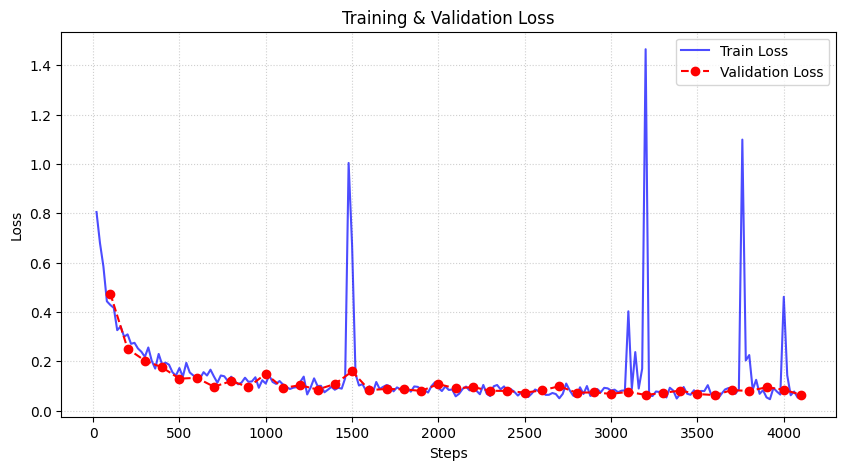

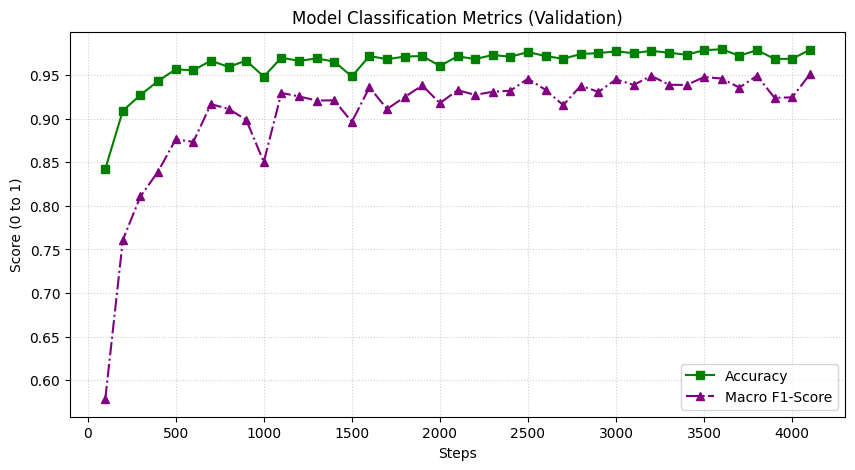

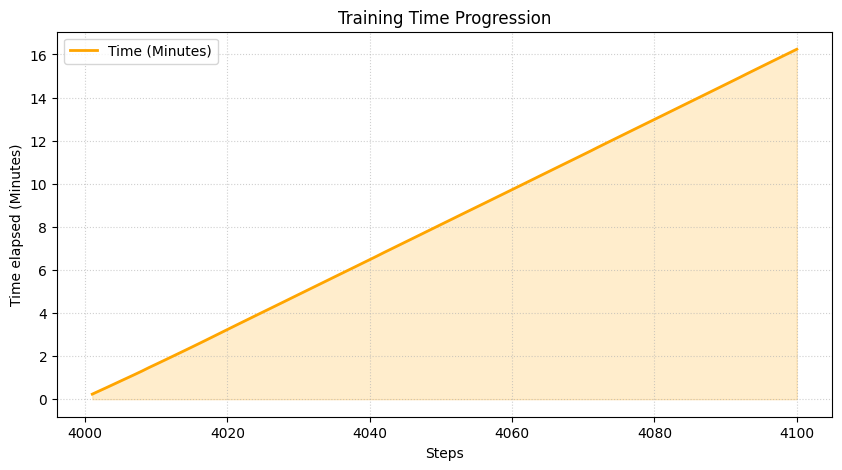


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
200,4020,2.005988,0.143072,0.000182,NaN,NaN,NaN,NaN,NaN,3.236414
201,4040,2.015968,0.061997,0.000181,NaN,NaN,NaN,NaN,NaN,6.478931
202,4060,2.025948,0.077176,0.000181,NaN,NaN,NaN,NaN,NaN,9.727101
203,4080,2.035928,0.052998,0.000181,NaN,NaN,NaN,NaN,NaN,12.984001
204,4100,2.045908,0.052299,0.000181,0.063841,0.978701,0.953628,0.949645,0.950557,16.241480



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-4100_2026-08-04_05-26-09


🚀 [Step 4100] Train Loss: 0.0479 | Train Acc: 0.9630

🚀 [Step 4100] Train Loss: 0.1123 | Train Acc: 0.9231

🚀 [Step 4120] Train Loss: 0.0395 | Train Acc: 0.9630

🚀 [Step 4120] Train Loss: 0.0049 | Train Acc: 1.0000

🚀 [Step 4140] Train Loss: 0.0072 | Train Acc: 1.0000

🚀 [Step 4140] Train Loss: 0.0041 | Train Acc: 1.0000

🚀 [Step 4160] Train Loss: 0.0174 | Train Acc: 1.0000

🚀 [Step 4160] Train Loss: 0.2431 | Train Acc: 0.9643

🚀 [Step 4180] Train Loss: 0.1584 | Train Acc: 0.9310

🚀 [Step 4180] Train Loss: 0.0338 | Train Acc: 0.9677

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-4200


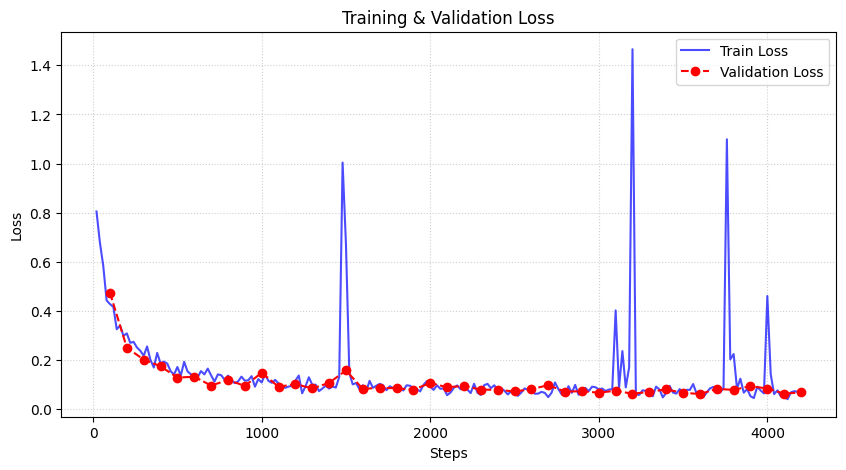

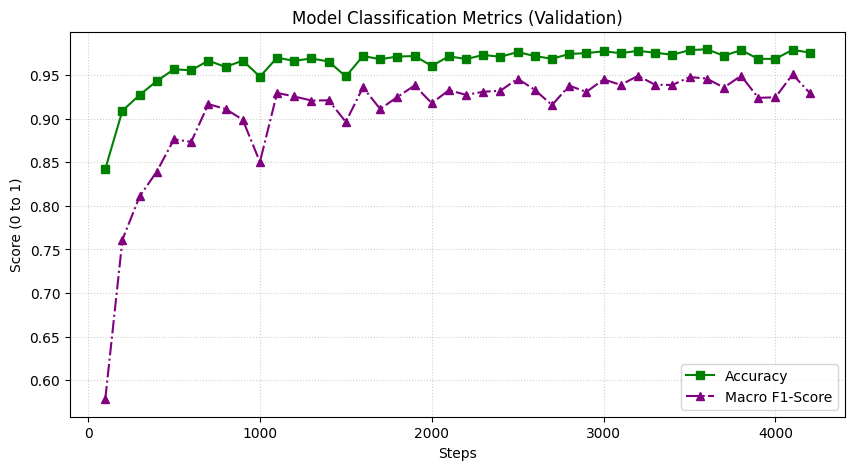

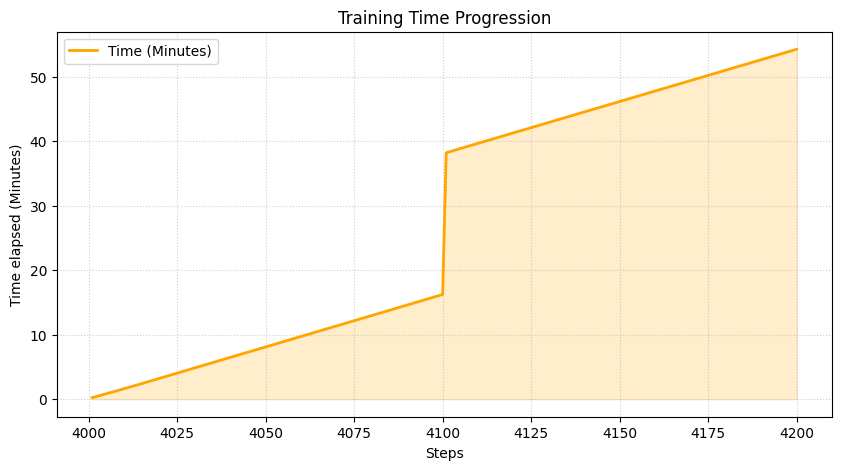


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
205,4120,2.055888,0.041141,0.000181,NaN,NaN,NaN,NaN,NaN,41.305080
206,4140,2.065868,0.069380,0.000181,NaN,NaN,NaN,NaN,NaN,44.537353
207,4160,2.075848,0.074014,0.000180,NaN,NaN,NaN,NaN,NaN,47.779399
208,4180,2.085828,0.071121,0.000180,NaN,NaN,NaN,NaN,NaN,51.028106
209,4200,2.095808,0.074099,0.000180,0.06907,0.975569,0.962093,0.919539,0.929155,54.271717



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-4200_2026-08-04_06-04-07


🚀 [Step 4200] Train Loss: 0.0012 | Train Acc: 1.0000

🚀 [Step 4200] Train Loss: 0.0179 | Train Acc: 1.0000

🚀 [Step 4220] Train Loss: 0.0030 | Train Acc: 1.0000

🚀 [Step 4220] Train Loss: 0.0017 | Train Acc: 1.0000

🚀 [Step 4240] Train Loss: 0.0158 | Train Acc: 1.0000

🚀 [Step 4240] Train Loss: 0.0112 | Train Acc: 1.0000

🚀 [Step 4260] Train Loss: 0.0613 | Train Acc: 0.9630

🚀 [Step 4260] Train Loss: 0.3271 | Train Acc: 0.8667

🚀 [Step 4280] Train Loss: 0.0529 | Train Acc: 1.0000

🚀 [Step 4280] Train Loss: 0.0131 | Train Acc: 1.0000

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-4300


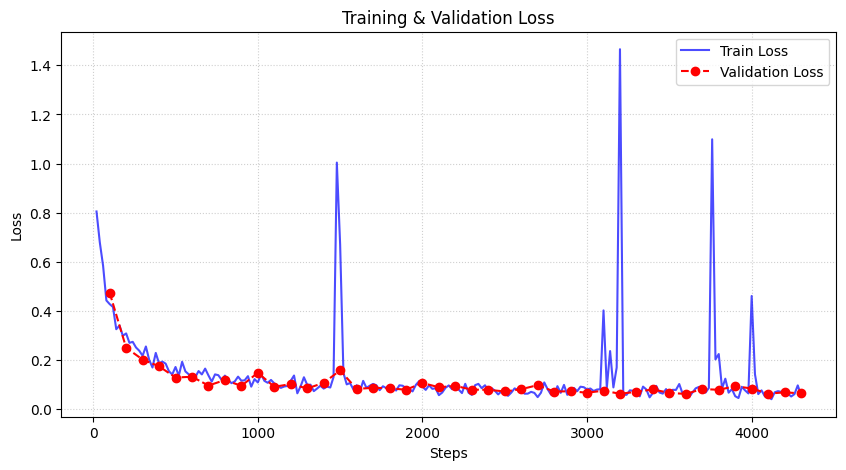

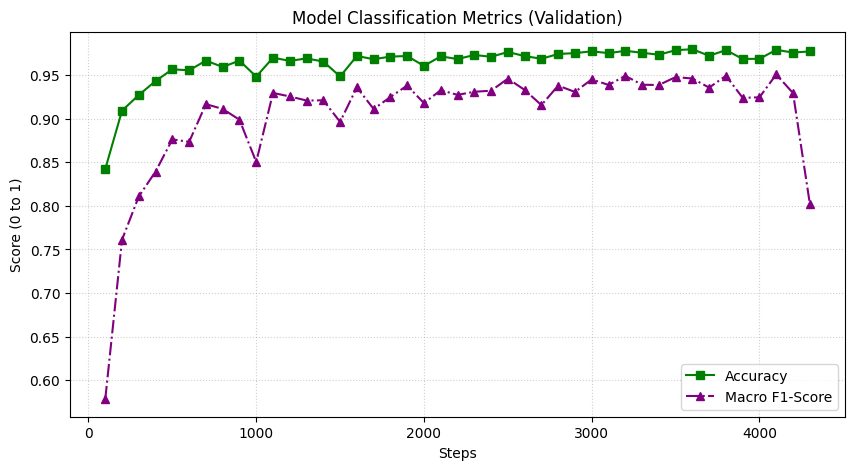

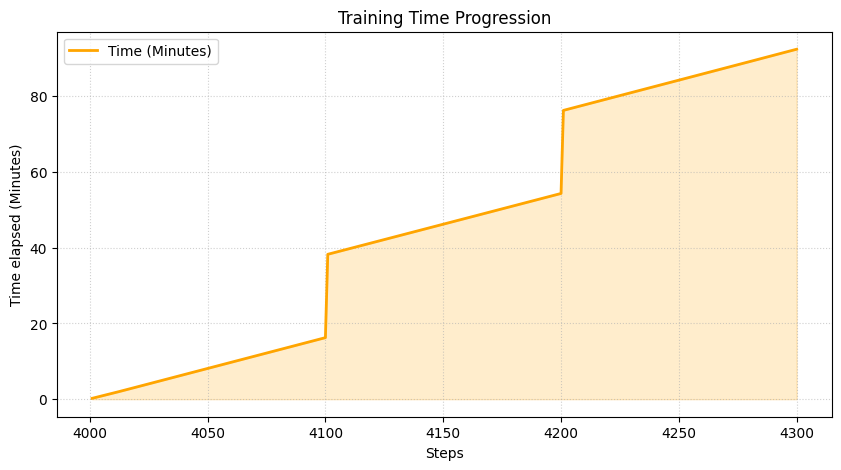


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
210,4220,2.105788,0.064277,0.000180,NaN,NaN,NaN,NaN,NaN,79.266772
211,4240,2.115768,0.052250,0.000180,NaN,NaN,NaN,NaN,NaN,82.502590
212,4260,2.125749,0.061922,0.000179,NaN,NaN,NaN,NaN,NaN,85.754894
213,4280,2.135729,0.097439,0.000179,NaN,NaN,NaN,NaN,NaN,89.045753
214,4300,2.145709,0.057562,0.000179,0.064983,0.976905,0.799948,0.813496,0.802579,92.316390



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-4300_2026-08-04_06-42-23


🚀 [Step 4300] Train Loss: 0.0572 | Train Acc: 0.9630

🚀 [Step 4300] Train Loss: 0.0824 | Train Acc: 0.9615

🚀 [Step 4320] Train Loss: 0.1017 | Train Acc: 0.9655

🚀 [Step 4320] Train Loss: 0.3918 | Train Acc: 0.9630

🚀 [Step 4340] Train Loss: 0.0082 | Train Acc: 1.0000

🚀 [Step 4340] Train Loss: 0.0262 | Train Acc: 1.0000

🚀 [Step 4360] Train Loss: 0.0444 | Train Acc: 0.9643

🚀 [Step 4360] Train Loss: 0.0179 | Train Acc: 1.0000

🚀 [Step 4380] Train Loss: 0.0168 | Train Acc: 1.0000

🚀 [Step 4380] Train Loss: 0.0053 | Train Acc: 1.0000

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-4400


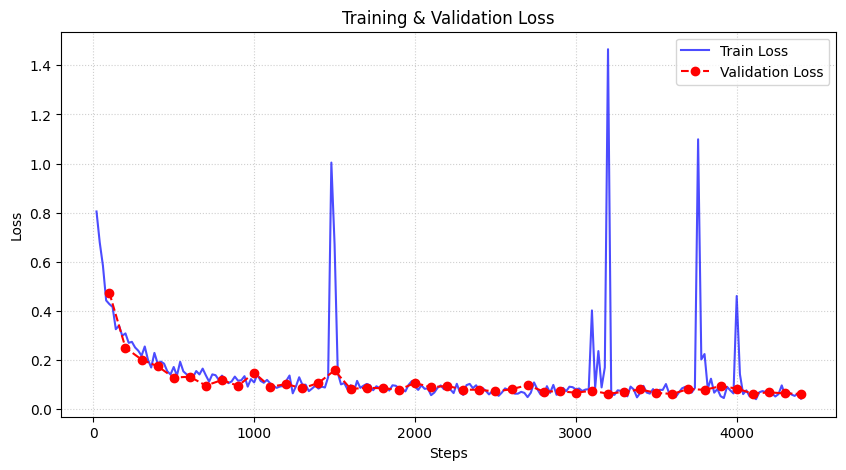

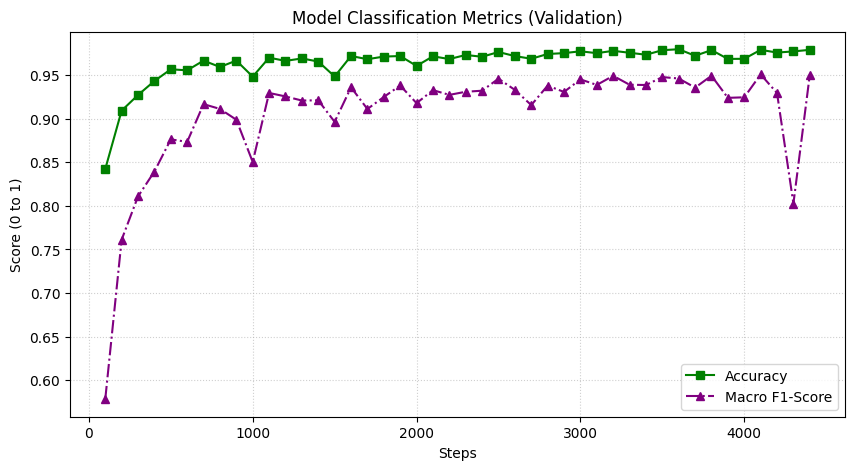

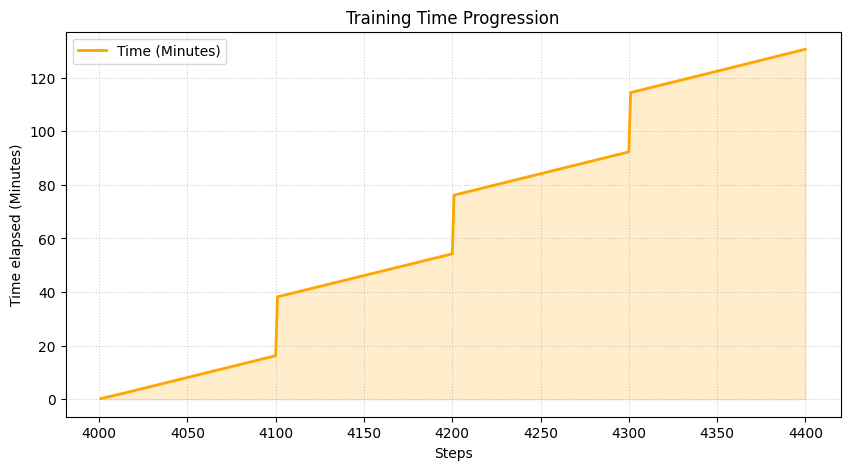


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
215,4320,2.155689,0.072872,0.000179,NaN,NaN,NaN,NaN,NaN,117.551570
216,4340,2.165669,0.060364,0.000179,NaN,NaN,NaN,NaN,NaN,120.816790
217,4360,2.175649,0.054737,0.000178,NaN,NaN,NaN,NaN,NaN,124.074994
218,4380,2.185629,0.063552,0.000178,NaN,NaN,NaN,NaN,NaN,127.362744
219,4400,2.195609,0.043390,0.000178,0.062612,0.978701,0.954829,0.948153,0.950195,130.641126



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-4400_2026-08-04_07-20-47


🚀 [Step 4400] Train Loss: 0.0136 | Train Acc: 1.0000

🚀 [Step 4400] Train Loss: 0.0224 | Train Acc: 1.0000

🚀 [Step 4420] Train Loss: 0.0482 | Train Acc: 0.9630

🚀 [Step 4420] Train Loss: 0.0537 | Train Acc: 0.9667

🚀 [Step 4440] Train Loss: 0.0065 | Train Acc: 1.0000

🚀 [Step 4440] Train Loss: 0.0263 | Train Acc: 1.0000

🚀 [Step 4460] Train Loss: 0.0374 | Train Acc: 1.0000

🚀 [Step 4460] Train Loss: 0.0337 | Train Acc: 1.0000

🚀 [Step 4480] Train Loss: 0.1209 | Train Acc: 0.9667

🚀 [Step 4480] Train Loss: 0.0286 | Train Acc: 1.0000

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-4500


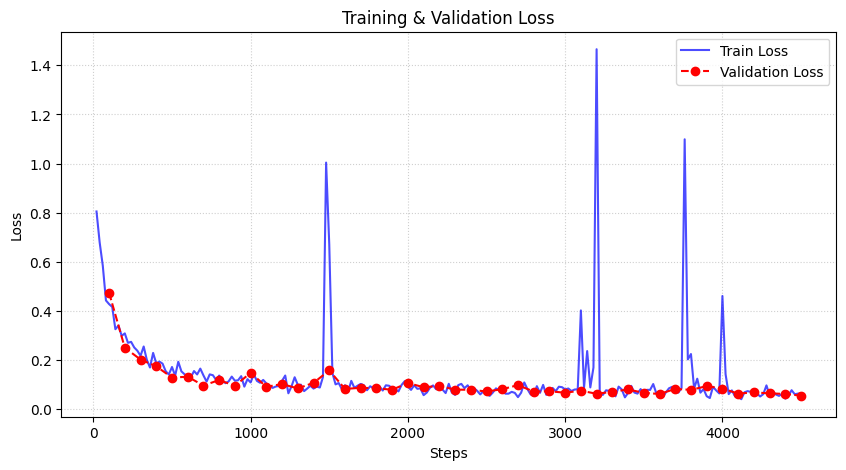

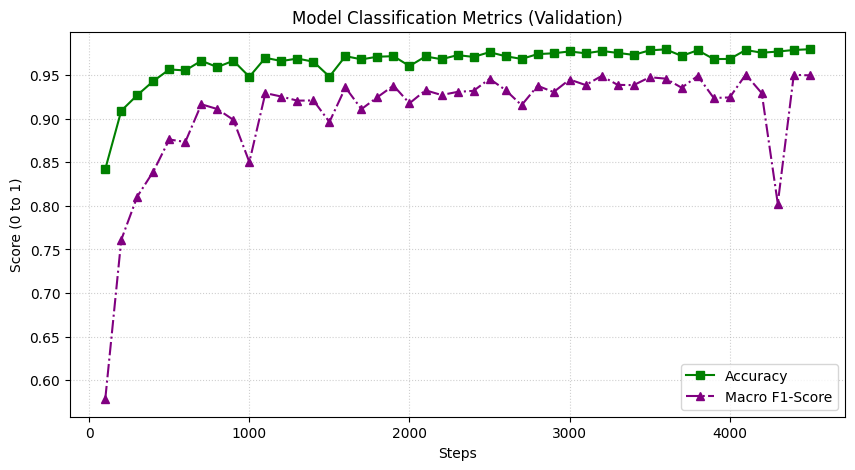

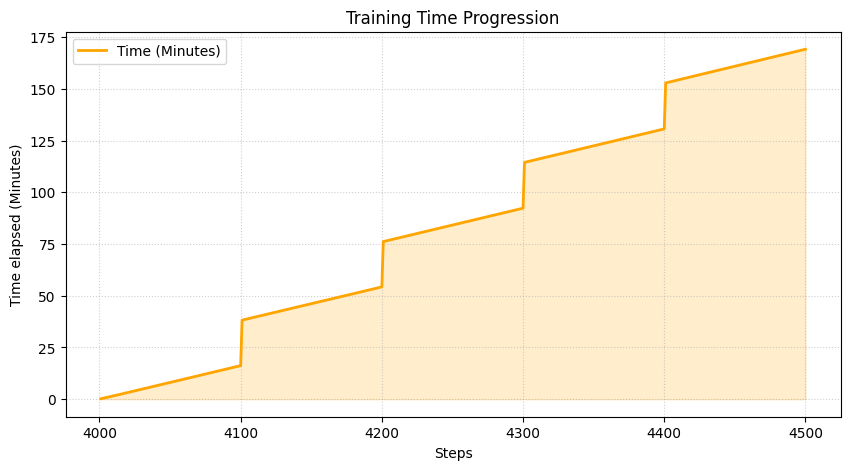


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
220,4420,2.205589,0.055989,0.000178,NaN,NaN,NaN,NaN,NaN,155.972328
221,4440,2.215569,0.077778,0.000178,NaN,NaN,NaN,NaN,NaN,159.257033
222,4460,2.225549,0.061301,0.000177,NaN,NaN,NaN,NaN,NaN,162.555933
223,4480,2.235529,0.064034,0.000177,NaN,NaN,NaN,NaN,NaN,165.841980
224,4500,2.245509,0.063353,0.000177,0.055534,0.979578,0.958153,0.94378,0.949625,169.135227



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-4500_2026-08-04_07-59-15


🚀 [Step 4500] Train Loss: 0.0453 | Train Acc: 0.9615

🚀 [Step 4500] Train Loss: 0.0073 | Train Acc: 1.0000

🚀 [Step 4520] Train Loss: 0.0121 | Train Acc: 1.0000

🚀 [Step 4520] Train Loss: 0.0007 | Train Acc: 1.0000

🚀 [Step 4540] Train Loss: 0.1761 | Train Acc: 0.9643

🚀 [Step 4540] Train Loss: 0.0018 | Train Acc: 1.0000

🚀 [Step 4560] Train Loss: 0.1598 | Train Acc: 0.9630

🚀 [Step 4560] Train Loss: 0.0583 | Train Acc: 0.9630

🚀 [Step 4580] Train Loss: 0.0865 | Train Acc: 0.9630

🚀 [Step 4580] Train Loss: 0.0894 | Train Acc: 0.9333

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-4600


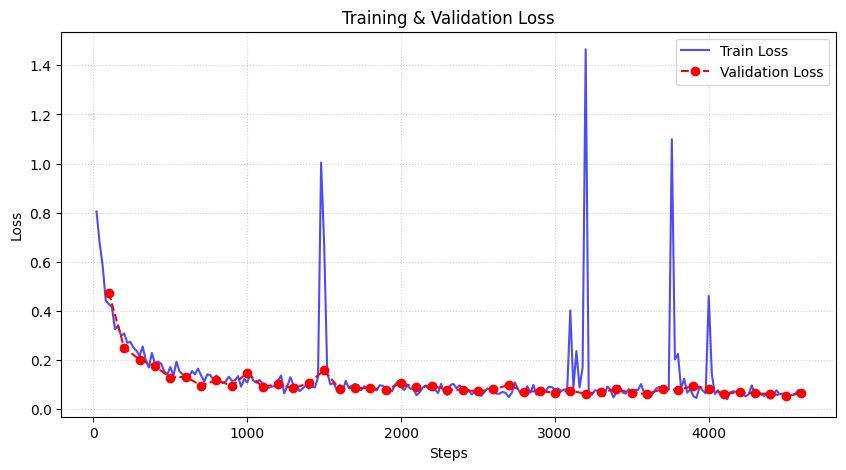

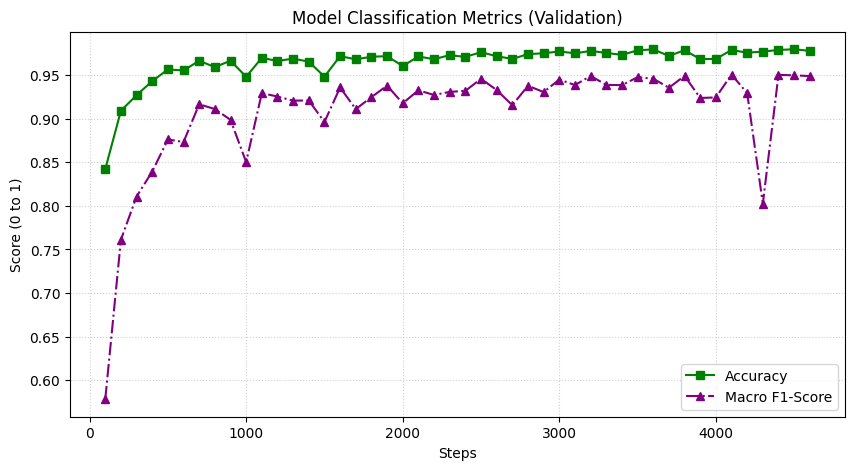

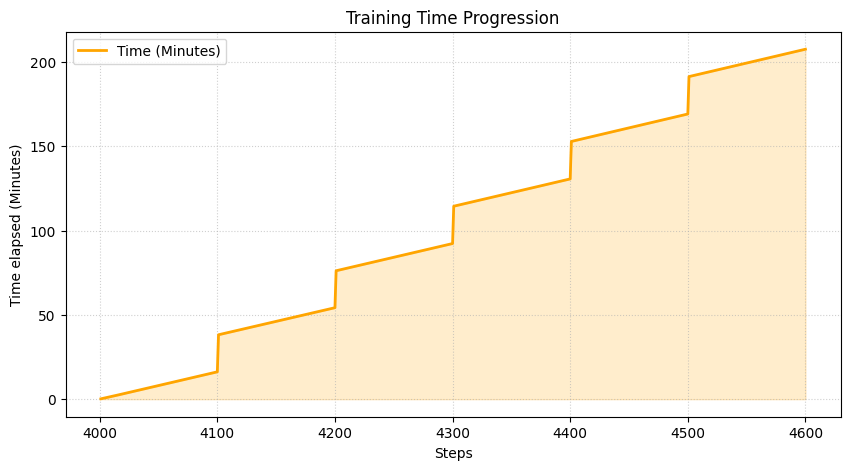


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
225,4520,2.255489,0.052251,0.000177,NaN,NaN,NaN,NaN,NaN,194.437076
226,4540,2.265469,0.058515,0.000177,NaN,NaN,NaN,NaN,NaN,197.715412
227,4560,2.275449,0.061201,0.000176,NaN,NaN,NaN,NaN,NaN,200.992506
228,4580,2.285429,0.078168,0.000176,NaN,NaN,NaN,NaN,NaN,204.264798
229,4600,2.295409,0.065262,0.000176,0.06533,0.977657,0.95795,0.942786,0.948797,207.547198



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-4600_2026-08-04_08-37-41


🚀 [Step 4600] Train Loss: 0.1075 | Train Acc: 0.9643

🚀 [Step 4600] Train Loss: 0.0209 | Train Acc: 1.0000

🚀 [Step 4620] Train Loss: 0.0046 | Train Acc: 1.0000

🚀 [Step 4620] Train Loss: 0.0193 | Train Acc: 1.0000

🚀 [Step 4640] Train Loss: 0.2109 | Train Acc: 0.9655

🚀 [Step 4640] Train Loss: 0.0586 | Train Acc: 1.0000

🚀 [Step 4660] Train Loss: 0.0602 | Train Acc: 1.0000

🚀 [Step 4660] Train Loss: 0.0079 | Train Acc: 1.0000

🚀 [Step 4680] Train Loss: 0.2454 | Train Acc: 0.9643

🚀 [Step 4680] Train Loss: 0.0880 | Train Acc: 0.9667

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-4700


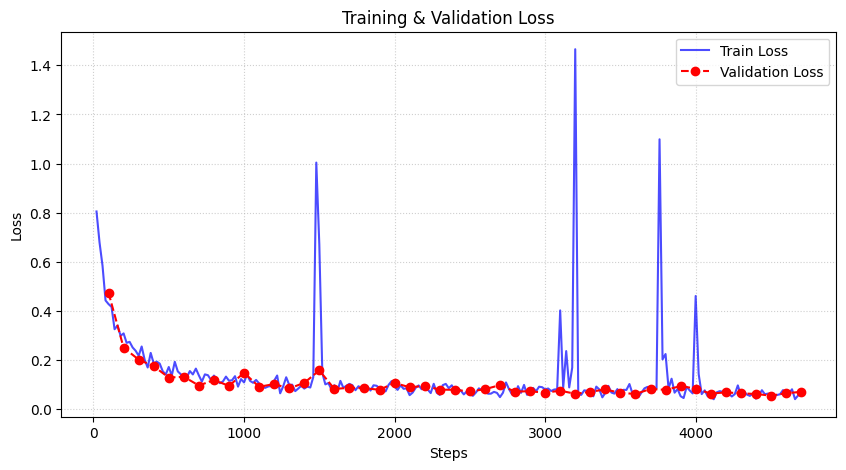

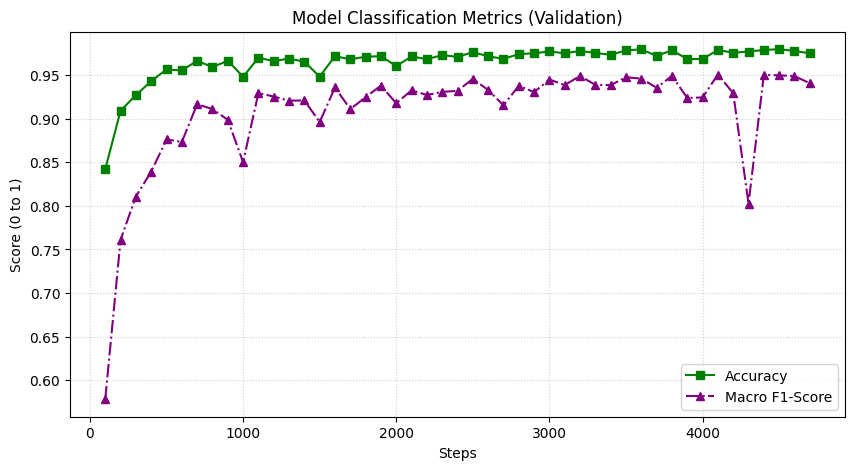

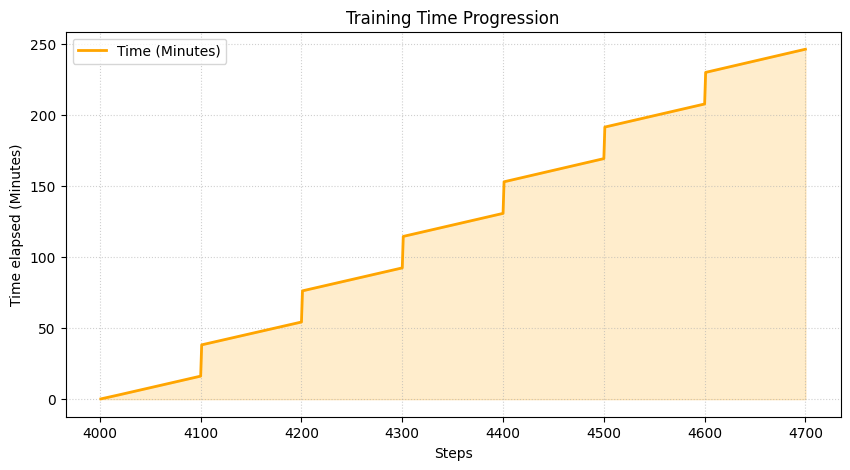


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
230,4620,2.305389,0.065547,0.000176,NaN,NaN,NaN,NaN,NaN,232.881739
231,4640,2.315369,0.081596,0.000176,NaN,NaN,NaN,NaN,NaN,236.178067
232,4660,2.325349,0.041395,0.000175,NaN,NaN,NaN,NaN,NaN,239.475533
233,4680,2.335329,0.056214,0.000175,NaN,NaN,NaN,NaN,NaN,242.758058
234,4700,2.345309,0.079414,0.000175,0.071247,0.974776,0.950315,0.93777,0.940554,246.041196



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-4700_2026-08-04_09-16-12


🚀 [Step 4700] Train Loss: 0.0061 | Train Acc: 1.0000

🚀 [Step 4700] Train Loss: 0.0278 | Train Acc: 0.9667

🚀 [Step 4720] Train Loss: 0.0230 | Train Acc: 1.0000

🚀 [Step 4720] Train Loss: 0.1847 | Train Acc: 0.9643

🚀 [Step 4740] Train Loss: 0.0351 | Train Acc: 1.0000

🚀 [Step 4740] Train Loss: 0.0769 | Train Acc: 0.9630

🚀 [Step 4760] Train Loss: 0.0033 | Train Acc: 1.0000

🚀 [Step 4760] Train Loss: 0.0330 | Train Acc: 0.9630

🚀 [Step 4780] Train Loss: 0.3566 | Train Acc: 0.9259

🚀 [Step 4780] Train Loss: 0.1093 | Train Acc: 0.9667

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-4800


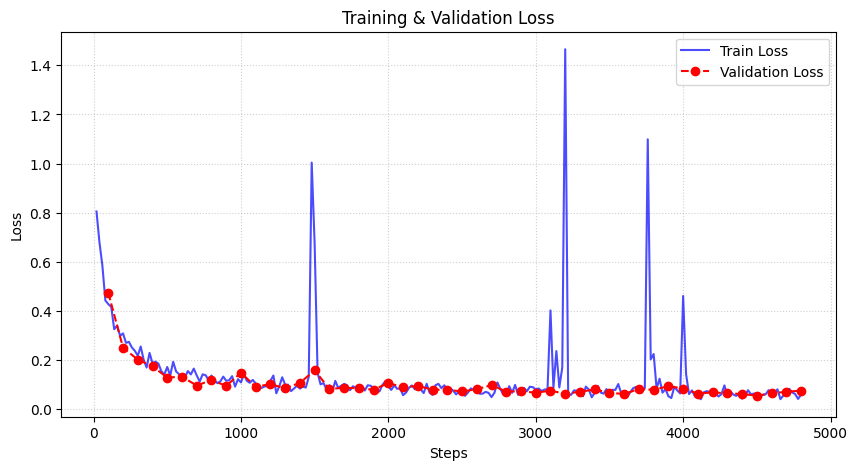

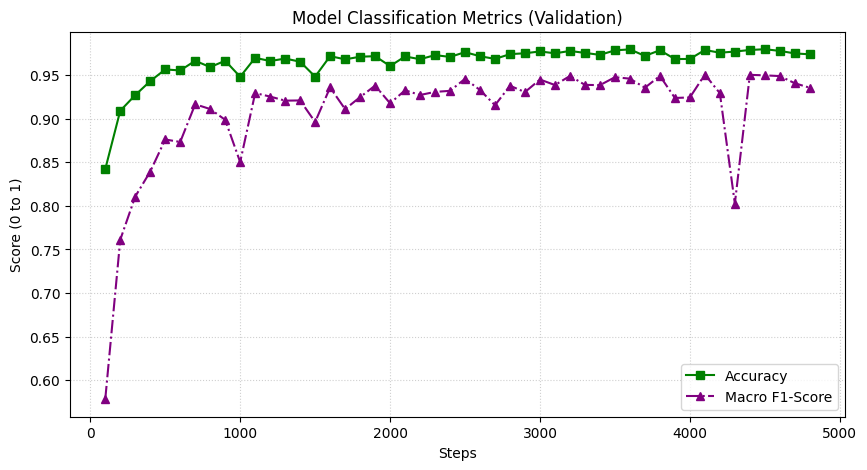

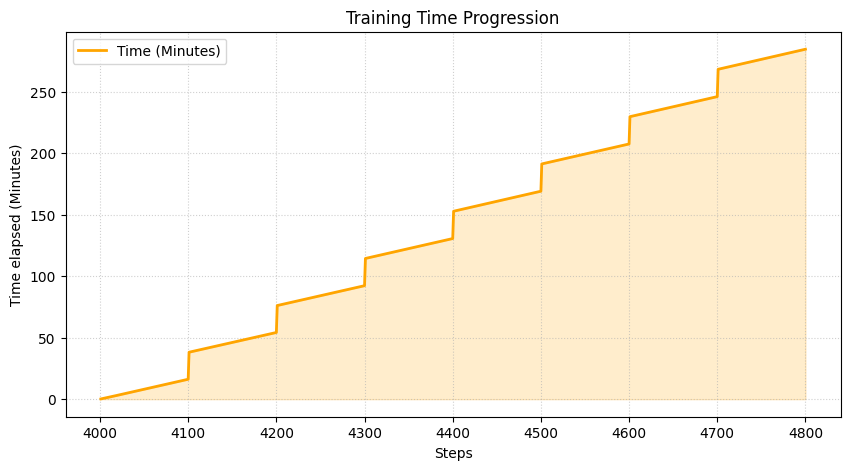


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
235,4720,2.355289,0.083386,0.000175,NaN,NaN,NaN,NaN,NaN,271.424903
236,4740,2.365269,0.068875,0.000175,NaN,NaN,NaN,NaN,NaN,274.724066
237,4760,2.375250,0.062123,0.000174,NaN,NaN,NaN,NaN,NaN,278.016561
238,4780,2.385230,0.042255,0.000174,NaN,NaN,NaN,NaN,NaN,281.308633
239,4800,2.395210,0.059664,0.000174,0.076194,0.973731,0.950193,0.927989,0.935407,284.588192



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-4800_2026-08-04_09-54-45


🚀 [Step 4800] Train Loss: 0.0981 | Train Acc: 0.9310

🚀 [Step 4800] Train Loss: 0.0155 | Train Acc: 1.0000

🚀 [Step 4820] Train Loss: 0.0171 | Train Acc: 1.0000

🚀 [Step 4820] Train Loss: 0.1343 | Train Acc: 0.9667

🚀 [Step 4840] Train Loss: 0.0916 | Train Acc: 0.9655

🚀 [Step 4840] Train Loss: 0.1111 | Train Acc: 0.9643

🚀 [Step 4860] Train Loss: 0.0761 | Train Acc: 0.9615

🚀 [Step 4860] Train Loss: 0.1444 | Train Acc: 0.9310

🚀 [Step 4880] Train Loss: 0.1046 | Train Acc: 0.9615

🚀 [Step 4880] Train Loss: 0.0422 | Train Acc: 0.9643

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-4900


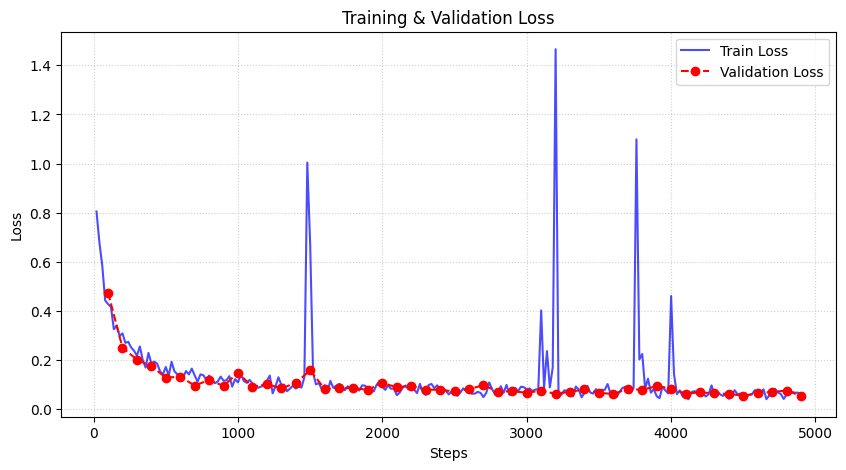

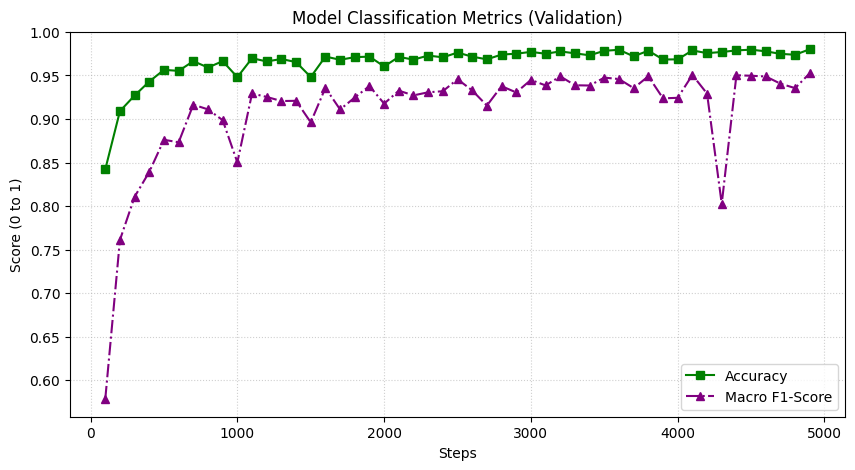

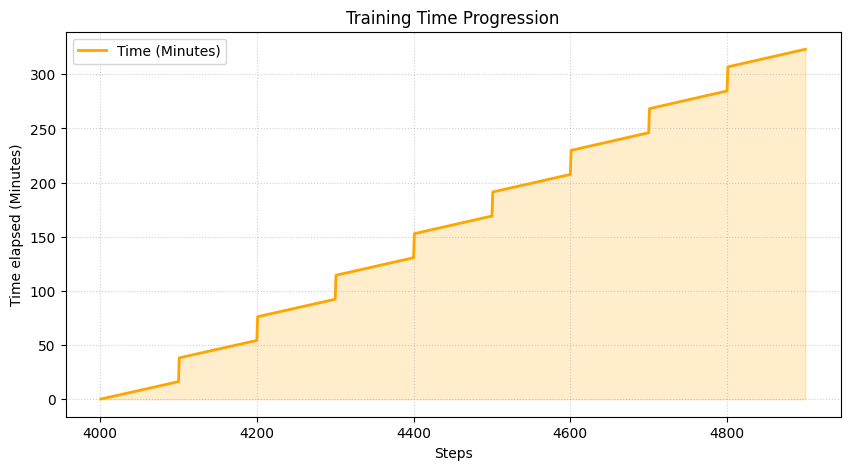


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
240,4820,2.40519,0.071601,0.000174,NaN,NaN,NaN,NaN,NaN,309.958370
241,4840,2.41517,0.070279,0.000174,NaN,NaN,NaN,NaN,NaN,313.254247
242,4860,2.42515,0.067591,0.000173,NaN,NaN,NaN,NaN,NaN,316.540258
243,4880,2.43513,0.067866,0.000173,NaN,NaN,NaN,NaN,NaN,319.833017
244,4900,2.44511,0.055197,0.000173,0.054828,0.980079,0.949724,0.958254,0.95259,323.115673



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-4900_2026-08-04_10-33-17


🚀 [Step 4900] Train Loss: 0.0133 | Train Acc: 1.0000

🚀 [Step 4900] Train Loss: 0.0073 | Train Acc: 1.0000

🚀 [Step 4920] Train Loss: 0.0947 | Train Acc: 0.9655

🚀 [Step 4920] Train Loss: 0.0278 | Train Acc: 1.0000

🚀 [Step 4940] Train Loss: 0.2062 | Train Acc: 0.9286

🚀 [Step 4940] Train Loss: 0.0022 | Train Acc: 1.0000

🚀 [Step 4960] Train Loss: 0.0082 | Train Acc: 1.0000

🚀 [Step 4960] Train Loss: 0.0143 | Train Acc: 1.0000

🚀 [Step 4980] Train Loss: 0.0038 | Train Acc: 1.0000

🚀 [Step 4980] Train Loss: 0.0056 | Train Acc: 1.0000

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-5000


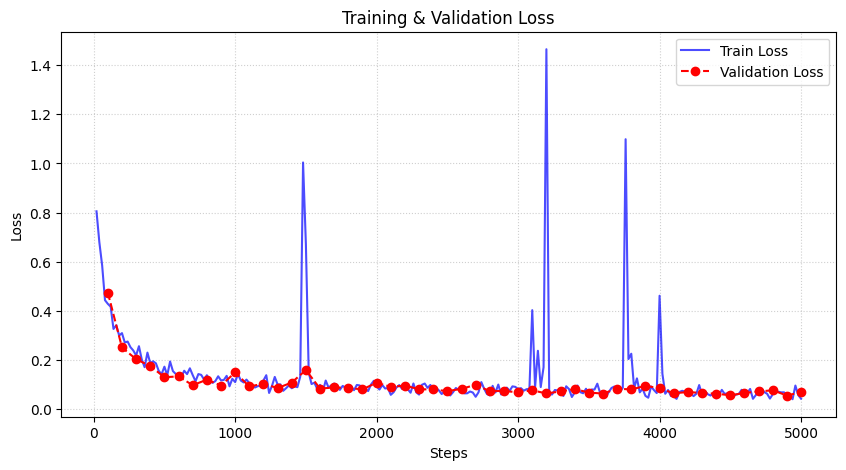

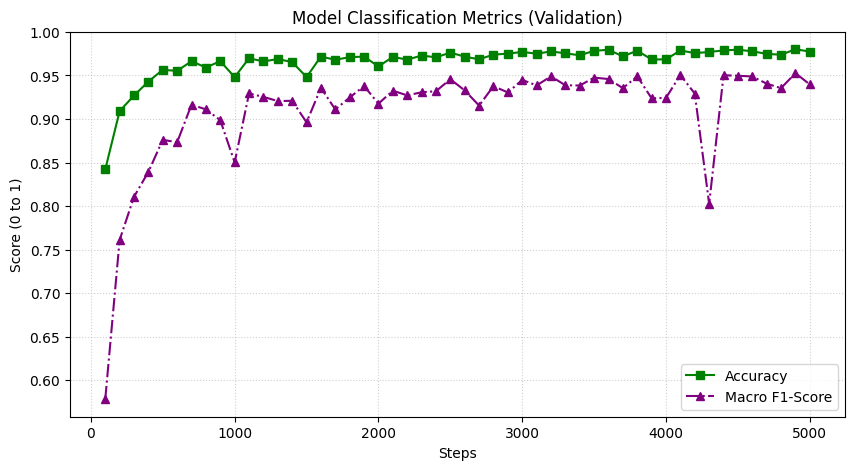

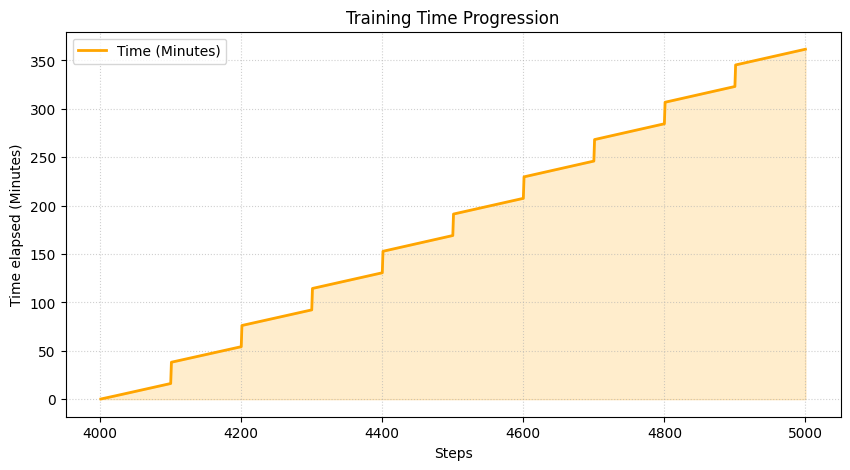


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
245,4920,2.45509,0.054973,0.000173,NaN,NaN,NaN,NaN,NaN,348.492905
246,4940,2.46507,0.039714,0.000172,NaN,NaN,NaN,NaN,NaN,351.783837
247,4960,2.47505,0.095425,0.000172,NaN,NaN,NaN,NaN,NaN,355.072149
248,4980,2.48503,0.056547,0.000172,NaN,NaN,NaN,NaN,NaN,358.347319
249,5000,2.49501,0.042056,0.000172,0.068354,0.977323,0.958388,0.932736,0.939669,361.615057



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-5000_2026-08-04_11-11-36


🚀 [Step 5000] Train Loss: 0.0441 | Train Acc: 1.0000

🚀 [Step 5000] Train Loss: 0.0905 | Train Acc: 0.9655

🚀 [Step 5020] Train Loss: 0.1017 | Train Acc: 0.9615

🚀 [Step 5020] Train Loss: 0.0005 | Train Acc: 1.0000

🚀 [Step 5040] Train Loss: 0.0018 | Train Acc: 1.0000

🚀 [Step 5040] Train Loss: 0.0241 | Train Acc: 1.0000

🚀 [Step 5060] Train Loss: 0.1058 | Train Acc: 0.9655

🚀 [Step 5060] Train Loss: 0.0120 | Train Acc: 1.0000

🚀 [Step 5080] Train Loss: 0.0522 | Train Acc: 1.0000

🚀 [Step 5080] Train Loss: 0.1253 | Train Acc: 0.9643

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-5100


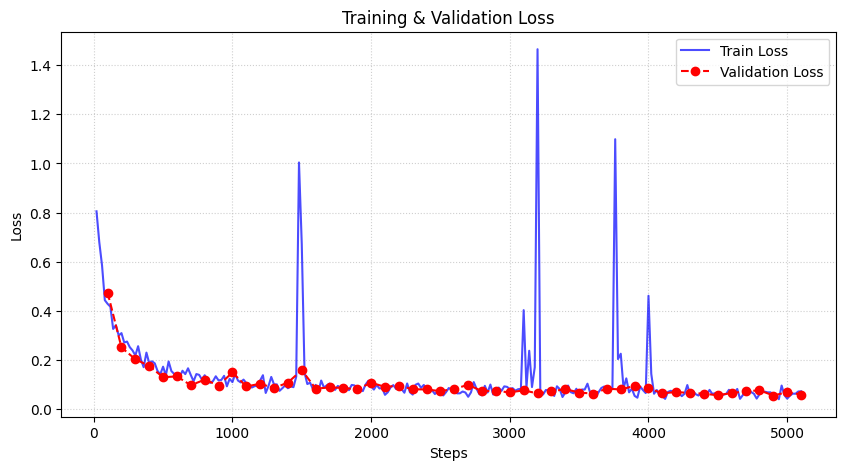

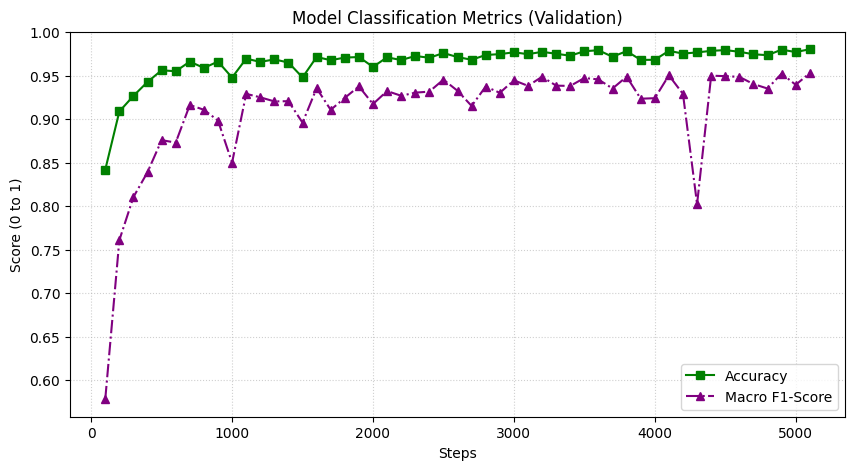

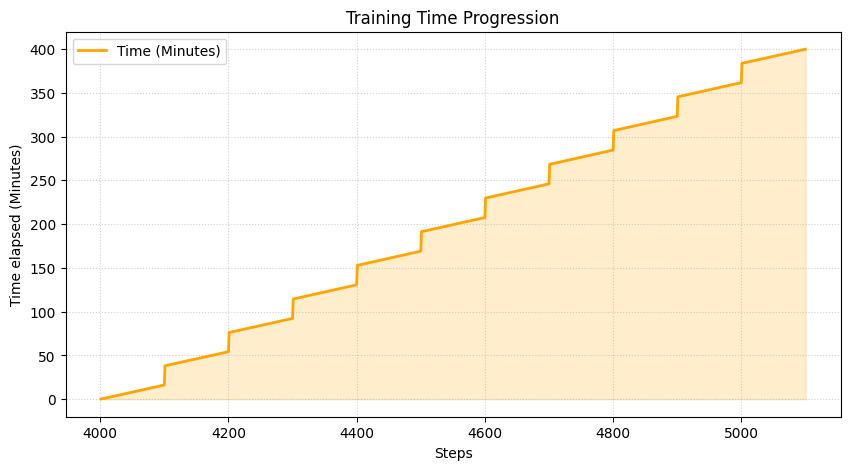


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
250,5020,2.50499,0.054558,0.000172,NaN,NaN,NaN,NaN,NaN,386.759536
251,5040,2.51497,0.062541,0.000171,NaN,NaN,NaN,NaN,NaN,390.002971
252,5060,2.52495,0.062027,0.000171,NaN,NaN,NaN,NaN,NaN,393.244470
253,5080,2.53493,0.071220,0.000171,NaN,NaN,NaN,NaN,NaN,396.489299
254,5100,2.54491,0.071906,0.000171,0.058849,0.98058,0.951043,0.95593,0.953194,399.733410



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-5100_2026-08-04_11-49-36


🚀 [Step 5100] Train Loss: 0.1609 | Train Acc: 0.9667

🚀 [Step 5100] Train Loss: 0.0219 | Train Acc: 1.0000

🚀 [Step 5120] Train Loss: 0.0791 | Train Acc: 0.9630

🚀 [Step 5120] Train Loss: 0.0230 | Train Acc: 1.0000

🚀 [Step 5140] Train Loss: 0.0247 | Train Acc: 1.0000

🚀 [Step 5140] Train Loss: 0.0234 | Train Acc: 1.0000

🚀 [Step 5160] Train Loss: 0.2025 | Train Acc: 0.8966

🚀 [Step 5160] Train Loss: 0.0585 | Train Acc: 0.9655

🚀 [Step 5180] Train Loss: 0.0497 | Train Acc: 1.0000

🚀 [Step 5180] Train Loss: 0.1881 | Train Acc: 0.9630

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-5200


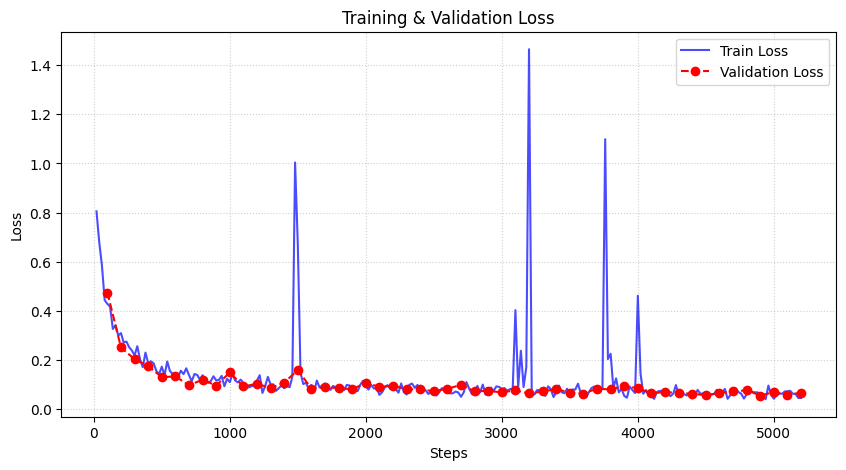

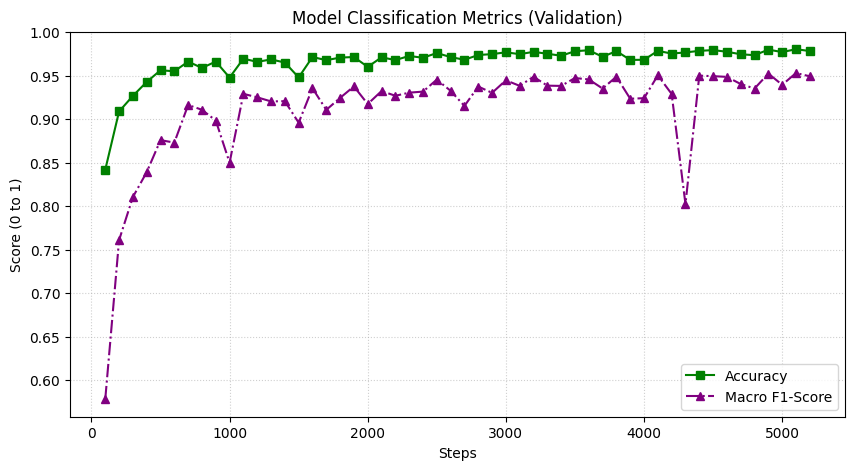

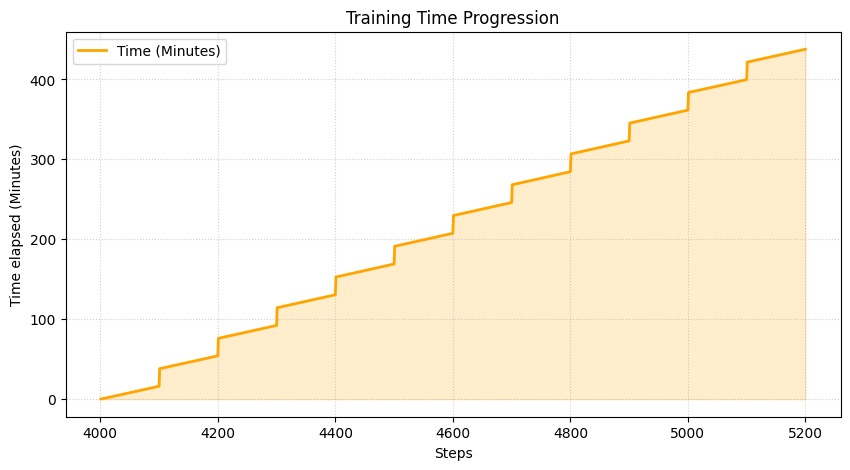


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
255,5120,2.55489,0.073976,0.00017,NaN,NaN,NaN,NaN,NaN,424.758159
256,5140,2.56487,0.062054,0.00017,NaN,NaN,NaN,NaN,NaN,428.009904
257,5160,2.57485,0.060926,0.00017,NaN,NaN,NaN,NaN,NaN,431.266056
258,5180,2.58483,0.044733,0.00017,NaN,NaN,NaN,NaN,NaN,434.509628
259,5200,2.59481,0.044634,0.00017,0.065723,0.978492,0.947299,0.95437,0.949468,437.754365



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-5200_2026-08-04_12-27-46


🚀 [Step 5200] Train Loss: 0.0192 | Train Acc: 1.0000

🚀 [Step 5200] Train Loss: 0.0219 | Train Acc: 1.0000

🚀 [Step 5220] Train Loss: 0.0163 | Train Acc: 1.0000

🚀 [Step 5220] Train Loss: 0.0160 | Train Acc: 1.0000

🚀 [Step 5240] Train Loss: 0.0170 | Train Acc: 1.0000

🚀 [Step 5240] Train Loss: 0.0085 | Train Acc: 1.0000

🚀 [Step 5260] Train Loss: 0.0786 | Train Acc: 0.9655

🚀 [Step 5260] Train Loss: 0.0210 | Train Acc: 1.0000

🚀 [Step 5280] Train Loss: 0.0075 | Train Acc: 1.0000

🚀 [Step 5280] Train Loss: 0.0492 | Train Acc: 1.0000

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-5300


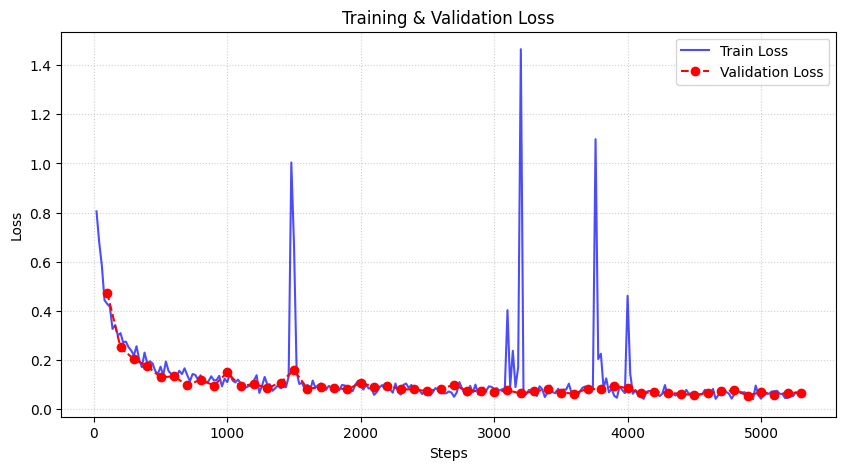

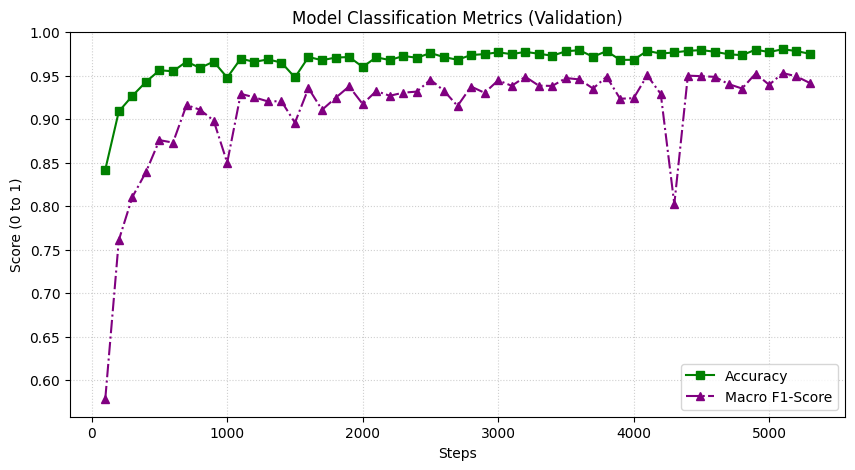

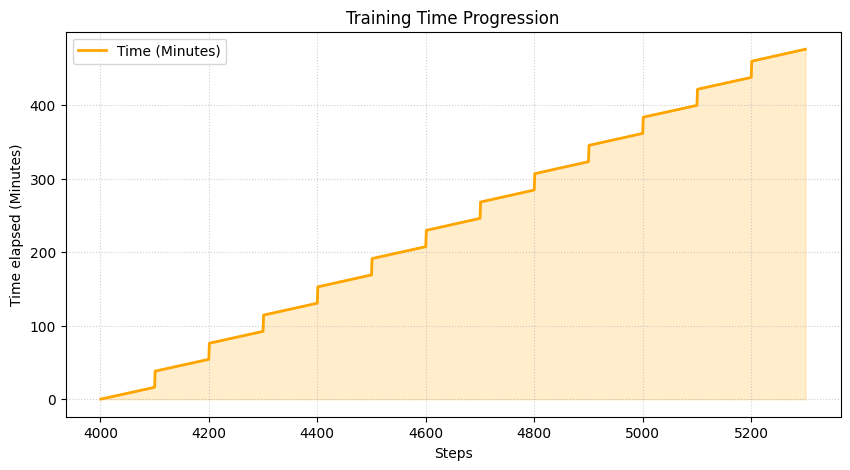


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
260,5220,2.604790,0.062304,0.000169,NaN,NaN,NaN,NaN,NaN,462.945262
261,5240,2.614770,0.051986,0.000169,NaN,NaN,NaN,NaN,NaN,466.238486
262,5260,2.624750,0.068835,0.000169,NaN,NaN,NaN,NaN,NaN,469.538970
263,5280,2.634731,0.057740,0.000169,NaN,NaN,NaN,NaN,NaN,472.830363
264,5300,2.644711,0.053669,0.000168,0.065551,0.975318,0.947381,0.942816,0.941776,476.111204



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-5300_2026-08-04_13-06-12


🚀 [Step 5300] Train Loss: 0.3664 | Train Acc: 0.9630

🚀 [Step 5300] Train Loss: 0.0133 | Train Acc: 1.0000

🚀 [Step 5320] Train Loss: 0.0095 | Train Acc: 1.0000

🚀 [Step 5320] Train Loss: 0.0297 | Train Acc: 1.0000

🚀 [Step 5340] Train Loss: 0.0119 | Train Acc: 1.0000

🚀 [Step 5340] Train Loss: 0.1057 | Train Acc: 0.9259

🚀 [Step 5360] Train Loss: 0.1045 | Train Acc: 0.9286

🚀 [Step 5360] Train Loss: 0.0163 | Train Acc: 1.0000

🚀 [Step 5380] Train Loss: 0.0044 | Train Acc: 1.0000

🚀 [Step 5380] Train Loss: 0.0026 | Train Acc: 1.0000

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-5400


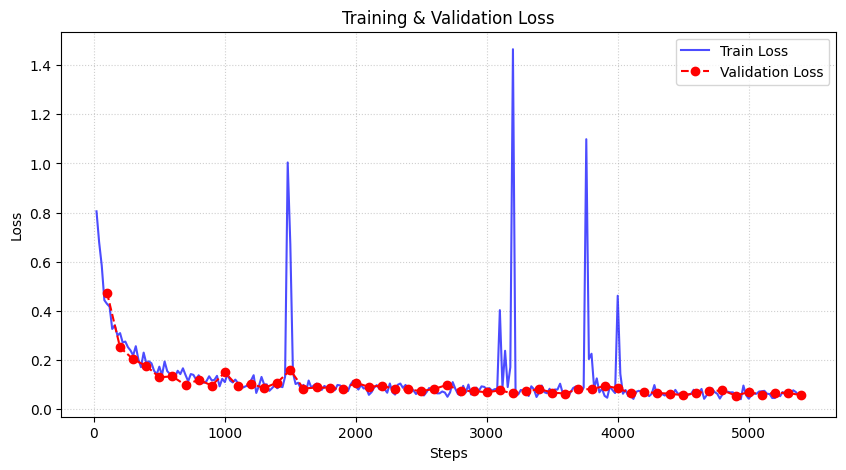

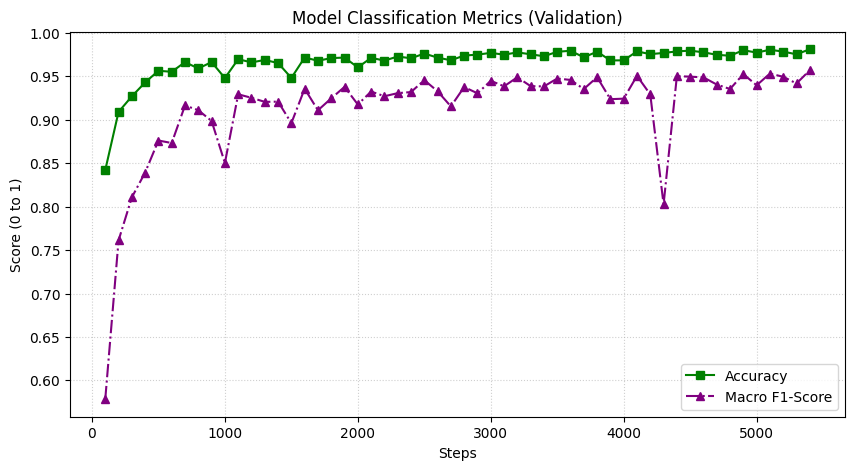

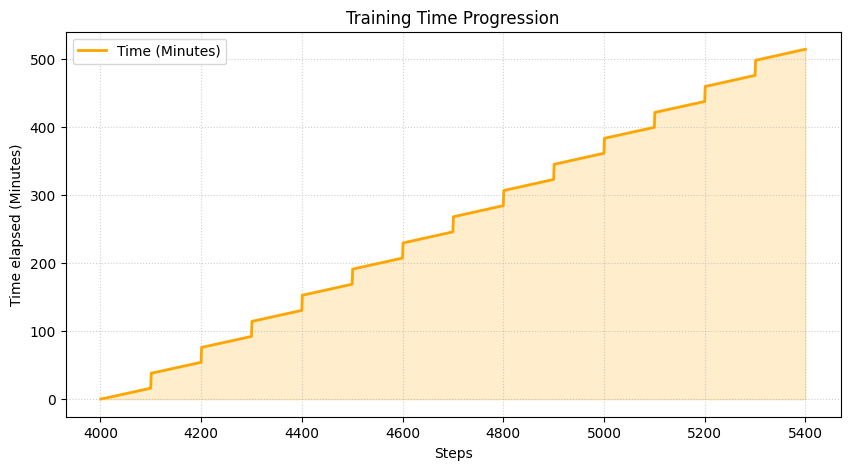


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
265,5320,2.654691,0.060657,0.000168,NaN,NaN,NaN,NaN,NaN,501.397363
266,5340,2.664671,0.076138,0.000168,NaN,NaN,NaN,NaN,NaN,504.701401
267,5360,2.674651,0.069013,0.000168,NaN,NaN,NaN,NaN,NaN,508.005213
268,5380,2.684631,0.056616,0.000167,NaN,NaN,NaN,NaN,NaN,511.289616
269,5400,2.694611,0.044935,0.000167,0.056242,0.981207,0.95758,0.957677,0.957035,514.580062



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-5400_2026-08-04_13-44-50


🚀 [Step 5400] Train Loss: 0.1092 | Train Acc: 1.0000

🚀 [Step 5400] Train Loss: 0.0134 | Train Acc: 1.0000

🚀 [Step 5420] Train Loss: 0.0033 | Train Acc: 1.0000

🚀 [Step 5420] Train Loss: 0.0153 | Train Acc: 1.0000

🚀 [Step 5440] Train Loss: 0.3259 | Train Acc: 0.9643

🚀 [Step 5440] Train Loss: 0.0012 | Train Acc: 1.0000

🚀 [Step 5460] Train Loss: 0.1014 | Train Acc: 0.9655

🚀 [Step 5460] Train Loss: 0.0281 | Train Acc: 1.0000

🚀 [Step 5480] Train Loss: 0.1013 | Train Acc: 0.9333

🚀 [Step 5480] Train Loss: 0.0001 | Train Acc: 1.0000

[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC checkpoint-5500


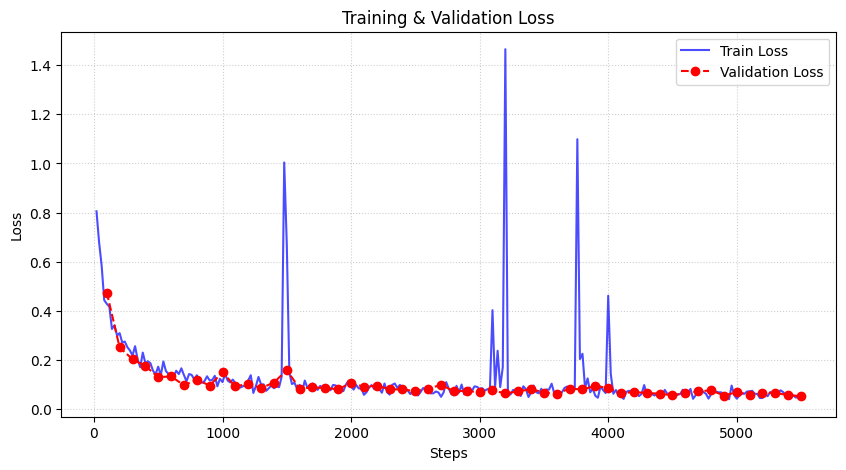

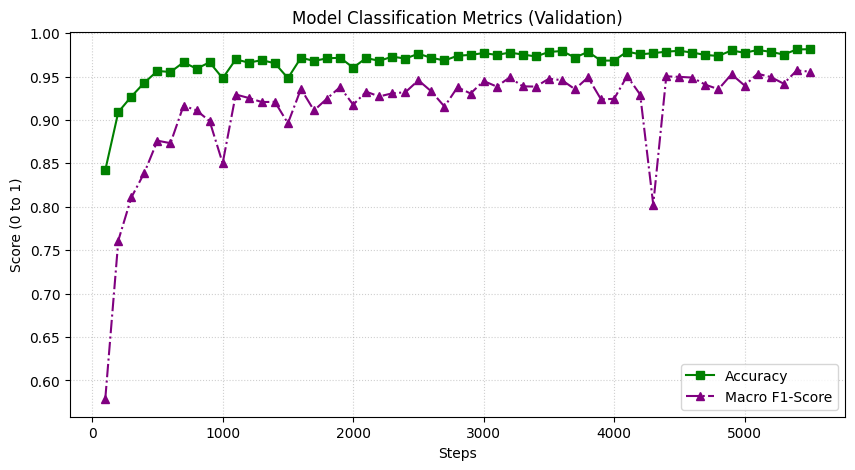

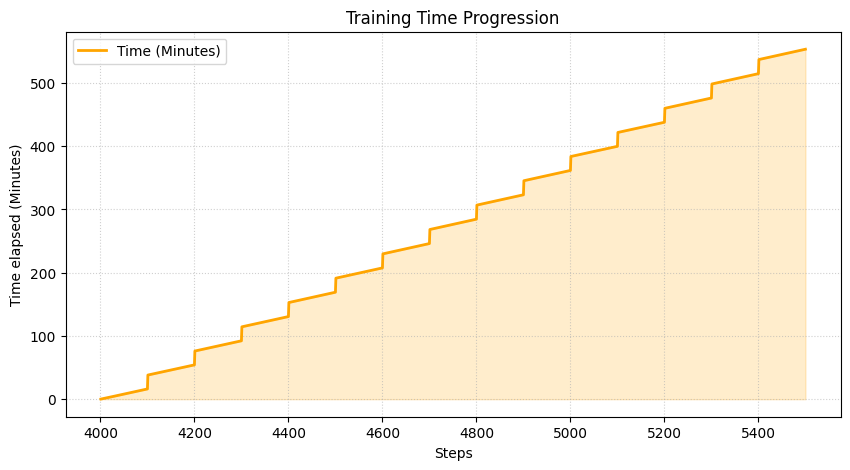


[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):


,step,epoch,loss,learning_rate,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1_score,elapsed_time_mins
270,5420,2.704591,0.053667,0.000167,NaN,NaN,NaN,NaN,NaN,540.018811
271,5440,2.714571,0.055543,0.000167,NaN,NaN,NaN,NaN,NaN,543.305476
272,5460,2.724551,0.046210,0.000167,NaN,NaN,NaN,NaN,NaN,546.603695
273,5480,2.734531,0.051440,0.000166,NaN,NaN,NaN,NaN,NaN,549.911976
274,5500,2.744511,0.058268,0.000166,0.052457,0.981458,0.95246,0.960271,0.95563,553.204807



[QWen] 💾 Toàn bộ file đã được lưu backup tại: /kaggle/working/outputs/qwen_blood_cell_v2/metrics_and_plots/checkpoint-5500_2026-08-04_14-23-30


🚀 [Step 5500] Train Loss: 0.0102 | Train Acc: 1.0000

🚀 [Step 5500] Train Loss: 0.0299 | Train Acc: 1.0000

🚀 [Step 5520] Train Loss: 0.0159 | Train Acc: 1.0000

🚀 [Step 5520] Train Loss: 0.0496 | Train Acc: 0.9615

🚀 [Step 5540] Train Loss: 0.0078 | Train Acc: 1.0000

🚀 [Step 5540] Train Loss: 0.0614 | Train Acc: 0.9630

🚀 [Step 5560] Train Loss: 0.1004 | Train Acc: 0.9643

🚀 [Step 5560] Train Loss: 0.0412 | Train Acc: 0.9655

🚀 [Step 5580] Train Loss: 0.0081 | Train Acc: 1.0000

🚀 [Step 5580] Train Loss: 0.0911 | Train Acc: 0.9286


KeyboardInterrupt: 

In [3]:
import os
import sys
import json
import csv
import torch
import random
import time
import numpy as np
import pandas as pd
from IPython.display import display
from pathlib import Path
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
    TrainerCallback 
)
from transformers.trainer_utils import get_last_checkpoint
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)
import warnings
warnings.filterwarnings("ignore")

# ─── Configuration ───────────────────────────────────────────
WORKING_DATASET_DIR = Path("/kaggle/working/dataset_split") # Đọc từ thư mục Cell 1 tạo ra
OUTPUT_DIR = Path("/kaggle/working/outputs/qwen_blood_cell_v2")
METRICS_DIR = OUTPUT_DIR / "metrics_and_plots" 
BASE_MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

# Training hyperparameters
EPOCHS = 10 
BATCH_SIZE = 8
GRADIENT_ACCUMULATION = 2
LEARNING_RATE = 2e-4
MAX_GRAD_NORM = 1.0
LOGGING_STEPS = 20
SAVE_STEPS = 100
EVAL_STEPS = 100

# QLoRA config
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.2
USE_4BIT = True
BNB_4BIT_QUANT_TYPE = "nf4"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IMG_SIZE = 224

CELL_LABELS = ["BA", "BNE", "EO", "ERB", "LY", "MMY", "MO", "MY", "MYO", "PLT", "PMY", "SNE"]
CELL_NAMES = {
    "BA": "Basophil", "BNE": "Band Neutrophil", "EO": "Eosinophil",
    "ERB": "Erythroblast", "LY": "Lymphocyte", "MMY": "Metamyelocyte",
    "MO": "Monocyte", "MY": "Myelocyte", "MYO": "Myeloblast",
    "PLT": "Platelet", "PMY": "Promyelocyte", "SNE": "Segmented Neutrophil"
}

# ─── Load Dataset Từ Thư Mục Đã Chia ───────────────────────────
def load_prepared_dataset():
    train_dir = WORKING_DATASET_DIR / "train"
    val_dir = WORKING_DATASET_DIR / "val" # Chỉ nạp tập Val để Trainer đánh giá

    if not WORKING_DATASET_DIR.exists():
        print(f"[LỖI] Thư mục {WORKING_DATASET_DIR} chưa tồn tại. Vui lòng chạy Cell 1 trước!")
        sys.exit(1)

    train_data, val_data = [], []
    for label in CELL_LABELS:
        train_class_dir = train_dir / label
        val_class_dir = val_dir / label
        
        if train_class_dir.exists():
            for img_path in train_class_dir.glob("*"):
                train_data.append({"image_path": str(img_path), "label": label})
        if val_class_dir.exists():
            for img_path in val_class_dir.glob("*"):
                val_data.append({"image_path": str(img_path), "label": label})
                
    random.shuffle(train_data)
    random.shuffle(val_data)
    print(f"[QWen] Đã load dữ liệu | Train size: {len(train_data)} | Validation size: {len(val_data)}")
    return train_data, val_data

def build_prompt():
    cell_list = ", ".join(CELL_LABELS)
    prompt = f"This is a microscopic image of a blood cell. Classify this cell into exactly one of these categories: {cell_list}. These are abbreviations for: "
    for cl in CELL_LABELS: prompt += f"{cl}={CELL_NAMES[cl]}, "
    prompt = prompt.rstrip(", ") + ". Reply with ONLY the abbreviation code (e.g., 'LY')."
    return prompt

class BloodCellDataset(torch.utils.data.Dataset):
    def __init__(self, data_list, processor, is_train=True):
        self.data = data_list
        self.processor = processor
        self.is_train = is_train
        self.train_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=45), transforms.ColorJitter(brightness=0.1, contrast=0.1)
        ])
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        if self.is_train: image = self.train_transform(image)
        image = image.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        
        prompt = build_prompt()
        prompt_messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}]
        prompt_text = self.processor.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
        prompt_inputs = self.processor(text=[prompt_text], images=[image], padding=False, return_tensors="pt")
        prompt_len = prompt_inputs["input_ids"].shape[1]

        messages = [
            {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]},
            {"role": "assistant", "content": [{"type": "text", "text": item["label"]}]}
        ]
        text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        batch = self.processor(text=[text], images=[image], padding=False, return_tensors="pt")
        
        result = {k: (v if k in ["pixel_values", "image_grid_thw"] else v[0]) for k, v in batch.items()}
        labels = result["input_ids"].clone()
        labels[:prompt_len] = -100
        result["labels"] = labels
        return result

# ─── Model Setup ─────────────────────────────────────────────
def setup_model():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type=BNB_4BIT_QUANT_TYPE, bnb_4bit_use_double_quant=True,
    ) if USE_4BIT else None
    
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        BASE_MODEL_NAME, quantization_config=bnb_config, device_map="auto" if DEVICE == "cuda" else None,
        torch_dtype=torch.float16, attn_implementation="sdpa", low_cpu_mem_usage=True, trust_remote_code=True,
    )
    processor = AutoProcessor.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True, use_fast=False)
    
    if USE_4BIT: model = prepare_model_for_kbit_training(model)
    lora_config = LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT, bias="none", task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    )
    model = get_peft_model(model, lora_config)
    model.enable_input_require_grads()
    model.config.use_cache = False
    return model, processor

# ─── Tính Precision, Recall, F1 ───────────────────────────
def preprocess_logits_for_metrics(logits, labels):
    return logits[0].argmax(dim=-1) if isinstance(logits, tuple) else logits.argmax(dim=-1)

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds = preds[:, :-1]
    labels = labels[:, 1:]
    
    mask = labels != -100
    preds_flat = preds[mask].flatten()
    labels_flat = labels[mask].flatten()
    
    acc = accuracy_score(labels_flat, preds_flat)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_flat, preds_flat, average="macro", zero_division=0
    )
    
    return {
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1)
    }

# ─── Callback Nâng Cấp Xuất Dữ Liệu Chuyên Sâu ───
class PlotMetricsCallback(TrainerCallback):
    def __init__(self, metrics_base_dir):
        self.metrics_base_dir = Path(metrics_base_dir)
        self.metrics_base_dir.mkdir(parents=True, exist_ok=True)
        self.start_time = None
        self.step_times = {}

    def on_train_begin(self, args, state, control, **kwargs):
        self.start_time = time.time()

    def on_step_end(self, args, state, control, **kwargs):
        if self.start_time is not None:
            self.step_times[state.global_step] = time.time() - self.start_time

    def _export_and_plot(self, state, prefix):
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        save_dir = self.metrics_base_dir / f"{prefix}_{timestamp}"
        save_dir.mkdir(parents=True, exist_ok=True)
        log_history = state.log_history
        
        with open(save_dir / "training_logs_raw.json", "w", encoding="utf-8") as f:
            json.dump(log_history, f, indent=4)

        steps_data = {}
        for log in log_history:
            step = log.get("step")
            if step is None: continue
            if step not in steps_data: steps_data[step] = {"step": step}
            steps_data[step].update(log)
            if step in self.step_times:
                steps_data[step]["elapsed_time_mins"] = self.step_times[step] / 60.0
            
        csv_file = save_dir / "training_history_report.csv"
        csv_columns = ["step", "epoch", "loss", "learning_rate", "eval_loss", "eval_accuracy", "eval_precision", "eval_recall", "eval_f1_score", "elapsed_time_mins"]
        
        with open(csv_file, "w", newline="", encoding="utf-8") as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=csv_columns, extrasaction='ignore')
            writer.writeheader()
            for step in sorted(steps_data.keys()):
                writer.writerow(steps_data[step])

        train_steps, train_loss, lrs = [], [], []
        eval_steps, eval_loss, eval_acc, eval_f1 = [], [], [], []

        for step in sorted(steps_data.keys()):
            data = steps_data[step]
            if "loss" in data:
                train_steps.append(step)
                train_loss.append(data["loss"])
                if "learning_rate" in data: lrs.append(data["learning_rate"])
            if "eval_loss" in data:
                eval_steps.append(step)
                eval_loss.append(data["eval_loss"])
                eval_acc.append(data.get("eval_accuracy", 0))
                eval_f1.append(data.get("eval_f1_score", 0))

        print(f"\n=======================================================")
        print(f"[QWen] 📊 ĐANG XUẤT DỮ LIỆU TẠI BƯỚC {prefix}")
        print(f"=======================================================")

        if train_loss or eval_loss:
            plt.figure(figsize=(10, 5))
            if train_loss: plt.plot(train_steps, train_loss, label="Train Loss", color="blue", alpha=0.7)
            if eval_loss: plt.plot(eval_steps, eval_loss, label="Validation Loss", color="red", marker="o", linestyle="--")
            plt.xlabel("Steps")
            plt.ylabel("Loss")
            plt.title("Training & Validation Loss")
            plt.legend()
            plt.grid(True, linestyle=":", alpha=0.6)
            plt.savefig(save_dir / "plot_1_loss.png", dpi=300, bbox_inches="tight")
            plt.show() 
            plt.close()

        if eval_acc:
            plt.figure(figsize=(10, 5))
            plt.plot(eval_steps, eval_acc, label="Accuracy", color="green", marker="s", linestyle="-")
            if any(eval_f1):
                plt.plot(eval_steps, eval_f1, label="Macro F1-Score", color="purple", marker="^", linestyle="-.")
            plt.xlabel("Steps")
            plt.ylabel("Score (0 to 1)")
            plt.title("Model Classification Metrics (Validation)")
            plt.legend()
            plt.grid(True, linestyle=":", alpha=0.6)
            plt.savefig(save_dir / "plot_2_metrics.png", dpi=300, bbox_inches="tight")
            plt.show() 
            plt.close()
            
        if self.step_times:
            t_steps, t_vals = [], []
            for s in sorted(self.step_times.keys()):
                t_steps.append(s)
                t_vals.append(self.step_times[s] / 60.0)
            
            plt.figure(figsize=(10, 5))
            plt.plot(t_steps, t_vals, label="Time (Minutes)", color="orange", linewidth=2)
            plt.xlabel("Steps")
            plt.ylabel("Time elapsed (Minutes)")
            plt.title("Training Time Progression")
            plt.fill_between(t_steps, t_vals, color="orange", alpha=0.2)
            plt.legend()
            plt.grid(True, linestyle=":", alpha=0.6)
            plt.savefig(save_dir / "plot_3_time.png", dpi=300, bbox_inches="tight")
            plt.show()
            plt.close()
            
        try:
            df = pd.read_csv(csv_file)
            print("\n[QWen] 📄 Xem trước dữ liệu huấn luyện (5 lần check mới nhất):")
            display(df.tail(5)) 
        except Exception as e:
            pass

        print(f"\n[QWen] 💾 Toàn bộ file đã được lưu backup tại: {save_dir}\n")

    def on_save(self, args, state, control, **kwargs):
        self._export_and_plot(state, prefix=f"checkpoint-{state.global_step}")
        
    def on_train_end(self, args, state, control, **kwargs):
        self._export_and_plot(state, prefix="final_model")

# ─── Custom Trainer ────────────────────
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss = outputs.loss
        if model.training and self.state.global_step > 0 and self.state.global_step % self.args.logging_steps == 0:
            with torch.no_grad():
                logits = outputs.logits
                labels = inputs.get("labels")
                preds = logits.argmax(dim=-1)[:, :-1]
                labels_shifted = labels[:, 1:]
                mask = labels_shifted != -100
                correct = (preds == labels_shifted)[mask].sum().float()
                total = mask.sum().float()
                if total > 0:
                    train_acc = correct / total
                    print(f"\n🚀 [Step {self.state.global_step}] Train Loss: {loss.item():.4f} | Train Acc: {train_acc.item():.4f}")
        return (loss, outputs) if return_outputs else loss

# ─── Training Process ────────────────────────────────────────────────
def train():
    train_data, val_data = load_prepared_dataset()
    model, processor = setup_model()
    
    train_dataset = BloodCellDataset(train_data, processor, is_train=True)
    val_dataset = BloodCellDataset(val_data, processor, is_train=False)
    
    if processor.tokenizer.pad_token is None:
        processor.tokenizer.pad_token = processor.tokenizer.eos_token
        processor.tokenizer.pad_token_id = processor.tokenizer.eos_token_id
    pad_token_id = processor.tokenizer.pad_token_id

    training_args = TrainingArguments(
        output_dir=str(OUTPUT_DIR),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION,
        learning_rate=LEARNING_RATE,
        warmup_steps=int(len(train_dataset) / (BATCH_SIZE * GRADIENT_ACCUMULATION) * 0.05),
        logging_steps=LOGGING_STEPS,
        save_steps=SAVE_STEPS,
        eval_steps=EVAL_STEPS,
        eval_strategy="steps",
        save_strategy="steps",
        save_total_limit=2, 
        load_best_model_at_end=True,
        metric_for_best_model="f1_score", 
        greater_is_better=True,
        max_grad_norm=MAX_GRAD_NORM,
        fp16=True, 
        dataloader_num_workers=2,
        remove_unused_columns=False,
        report_to="none",
        seed=SEED,
        optim="adamw_8bit",
        lr_scheduler_type="cosine",
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": True},
    )
    
    def collate_fn(features):
        batch = {}
        for key in features[0].keys():
            if key in ["pixel_values", "image_grid_thw"]:
                tensors = [f[key] if f[key].dim() > 1 else f[key].unsqueeze(0) for f in features]
                batch[key] = torch.cat(tensors, dim=0)
            elif isinstance(features[0][key], torch.Tensor) and features[0][key].dim() == 1:
                max_len = max(f[key].size(0) for f in features)
                if key == "labels": padded = torch.full((len(features), max_len), -100, dtype=torch.long)
                elif key == "input_ids": padded = torch.full((len(features), max_len), pad_token_id, dtype=features[0][key].dtype)
                else: padded = torch.zeros((len(features), max_len), dtype=features[0][key].dtype)
                for i, f in enumerate(features): padded[i, :f[key].size(0)] = f[key]
                batch[key] = padded
            else: batch[key] = [f[key] for f in features]
        return batch
    
    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=collate_fn,
        processing_class=processor,
        compute_metrics=compute_metrics,
        preprocess_logits_for_metrics=preprocess_logits_for_metrics,
        callbacks=[
            PlotMetricsCallback(METRICS_DIR) 
        ]
    )
    
    last_checkpoint = None
    if OUTPUT_DIR.exists():
        checkpoints = sorted(list(OUTPUT_DIR.glob("checkpoint-*")), key=lambda x: int(x.name.split("-")[-1]))
        for cp in reversed(checkpoints):
            if ((cp / "adapter_model.safetensors").exists() or (cp / "adapter_model.bin").exists()) and (cp / "trainer_state.json").exists():
                last_checkpoint = str(cp)
                break

    print(f"\n[QWen] {'🔥 Đang chạy tiếp từ checkpoint: ' + last_checkpoint if last_checkpoint else '🚀 Bắt đầu train từ đầu'}")
    trainer.train(resume_from_checkpoint=last_checkpoint)
    
    trainer.save_model(str(OUTPUT_DIR / "final"))
    processor.save_pretrained(str(OUTPUT_DIR / "final"))
    
    print("\n[QWen] ✅ Hoàn tất! Quá trình Training kết thúc.")

if __name__ == "__main__":
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    train()

⚠️ Phát hiện torchao phiên bản 0.10.0 (không tương thích với PEFT).
🔄 Đang gỡ bỏ torchao để sử dụng PyTorch thuần...
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
✅ Đã gỡ bỏ torchao thành công!

🚀 Đang tải mô hình đã huấn luyện từ /kaggle/working/outputs/qwen_blood_cell_v2/checkpoint-4000...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/696 [00:00<?, ?it/s]


🔍 Đang tiến hành kiểm thử trên tập TEST độc lập...



Testing SNE : 100%|██████████| 778/778 [06:33<00:00,  1.98it/s]



📊 BÁO CÁO PHÂN LOẠI CHI TIẾT TRÊN TẬP TEST (FINAL TEST REPORT)
              precision    recall  f1-score   support

          BA     0.9803    0.8817    0.9283       338
         BNE     0.9286    0.7736    0.8440       773
          EO     0.9928    0.9878    0.9903       984
         ERB     0.9204    0.9678    0.9435       466
          LY     0.9882    0.7900    0.8780       957
         MMY     0.8847    0.5192    0.6544       547
          MO     0.7925    0.9563    0.8668       687
          MY     0.4076    0.9717    0.5743       565
         MYO     0.0000    0.0000    0.0000       279
         PLT     0.9875    0.9663    0.9767       326
         PMY     0.0000    0.0000    0.0000       183
         SNE     0.8384    0.9537    0.8924       778

    accuracy                         0.8168      6883
   macro avg     0.7268    0.7307    0.7124      6883
weighted avg     0.8185    0.8168    0.8007      6883



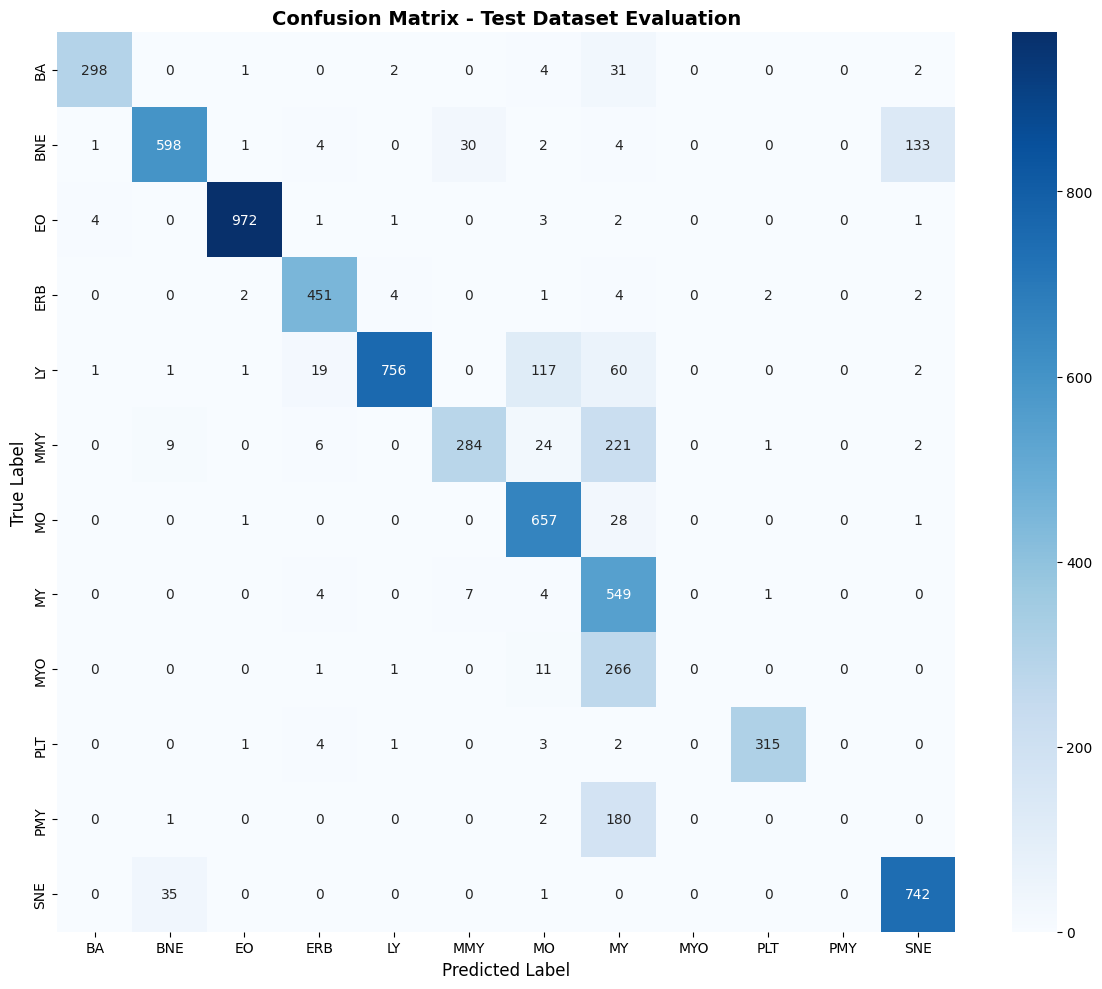


✅ Đã hoàn tất! Ma trận nhầm lẫn đã được lưu tại: /kaggle/working/outputs/qwen_blood_cell_v2/test_confusion_matrix.png
📄 Kết quả chi tiết từng ảnh đã được lưu tại: /kaggle/working/outputs/qwen_blood_cell_v2/test_predictions_detail.csv


In [4]:
# import sys
# import subprocess

# # ─── 0. TỰ ĐỘNG SỬA LỖI TORCHAO TRÊN KAGGLE ─────────────────────────
# try:
#     import torchao
#     print(f"⚠️ Phát hiện torchao phiên bản {torchao.__version__} (không tương thích với PEFT).")
#     print("🔄 Đang gỡ bỏ torchao để sử dụng PyTorch thuần...")
#     subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "torchao"], check=True)
#     print("✅ Đã gỡ bỏ torchao thành công!\n")
# except ImportError:
#     pass  # torchao chưa được cài đặt hoặc đã bị gỡ bỏ trước đó

# # ─── 1. IMPORT THƯ VIỆN ─────────────────────────────────────────────
# import os
# import torch
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from pathlib import Path
# from PIL import Image
# from tqdm import tqdm
# from sklearn.metrics import classification_report, confusion_matrix
# from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

# # ─── 2. CẤU HÌNH ĐƯỜNG DẪN & NHÃN ───────────────────────────────────
# TEST_DIR = Path("/kaggle/working/dataset_split/test")
# FINAL_MODEL_PATH = Path("/kaggle/working/outputs/qwen_blood_cell_v2/checkpoint-4000")

# CELL_LABELS = ["BA", "BNE", "EO", "ERB", "LY", "MMY", "MO", "MY", "MYO", "PLT", "PMY", "SNE"]
# CELL_NAMES = {
#     "BA": "Basophil", "BNE": "Band Neutrophil", "EO": "Eosinophil",
#     "ERB": "Erythroblast", "LY": "Lymphocyte", "MMY": "Metamyelocyte",
#     "MO": "Monocyte", "MY": "Myelocyte", "MYO": "Myeloblast",
#     "PLT": "Platelet", "PMY": "Promyelocyte", "SNE": "Segmented Neutrophil"
# }

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# # ─── 3. LOAD MÔ HÌNH ĐÃ FINE-TUNE ──────────────────────────────────
# if not FINAL_MODEL_PATH.exists():
#     print(f"❌ [LỖI] Không tìm thấy mô hình tại {FINAL_MODEL_PATH}. Vui lòng kiểm tra lại đường dẫn!")
# else:
#     print(f"🚀 Đang tải mô hình đã huấn luyện từ {FINAL_MODEL_PATH}...")
#     processor = AutoProcessor.from_pretrained(FINAL_MODEL_PATH, trust_remote_code=True)
#     model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
#         FINAL_MODEL_PATH,
#         device_map="auto" if DEVICE == "cuda" else None,
#         torch_dtype=torch.float16,
#         trust_remote_code=True
#     )
#     model.eval()

# # ─── 4. HÀM TẠO PROMPT VÀ DỰ ĐOÁN ──────────────────────────────────
# def build_prompt():
#     cell_list = ", ".join(CELL_LABELS)
#     prompt = f"This is a microscopic image of a blood cell. Classify this cell into exactly one of these categories: {cell_list}. These are abbreviations for: "
#     for cl in CELL_LABELS: 
#         prompt += f"{cl}={CELL_NAMES[cl]}, "
#     prompt = prompt.rstrip(", ") + ". Reply with ONLY the abbreviation code (e.g., 'LY')."
#     return prompt

# def predict_single_image(image_path):
#     image = Image.open(image_path).convert("RGB")
#     prompt = build_prompt()
#     messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}]
#     text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#     inputs = processor(text=[text], images=[image], padding=False, return_tensors="pt").to(DEVICE)
    
#     with torch.no_grad():
#         generated_ids = model.generate(**inputs, max_new_tokens=10)
    
#     # Cắt bỏ phần prompt đầu vào, chỉ lấy output sinh ra
#     generated_ids_trimmed = [
#         out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
#     ]
#     output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    
#     pred_clean = output_text.strip().upper()
#     # Tìm nhãn chính xác trong danh sách CELL_LABELS
#     for label in CELL_LABELS:
#         if label in pred_clean:
#             return label
#     return pred_clean

# # ─── 5. ĐÁNH GIÁ TRÊN TẬP TEST ─────────────────────────────────────
# def evaluate_test_set():
#     y_true, y_pred, test_results = [], [], []

#     print("\n🔍 Đang tiến hành kiểm thử trên tập TEST độc lập...\n")
    
#     for label in CELL_LABELS:
#         class_dir = TEST_DIR / label
#         if not class_dir.exists(): 
#             continue
        
#         images = list(class_dir.glob("*"))
#         images = [img for img in images if img.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']]
        
#         for img_path in tqdm(images, desc=f"Testing {label:<4}"):
#             pred = predict_single_image(img_path)
#             y_true.append(label)
#             y_pred.append(pred)
#             test_results.append({
#                 "image_path": str(img_path),
#                 "true_label": label,
#                 "pred_label": pred,
#                 "correct": label == pred
#             })

#     # 1. Báo cáo dạng văn bản (Classification Report)
#     print("\n" + "="*60)
#     print("📊 BÁO CÁO PHÂN LOẠI CHI TIẾT TRÊN TẬP TEST (FINAL TEST REPORT)")
#     print("="*60)
#     print(classification_report(y_true, y_pred, target_names=CELL_LABELS, digits=4, zero_division=0))

#     # 2. Vẽ và lưu Ma trận nhầm lẫn (Confusion Matrix)
#     cm = confusion_matrix(y_true, y_pred, labels=CELL_LABELS)
#     plt.figure(figsize=(12, 10))
#     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CELL_LABELS, yticklabels=CELL_LABELS)
#     plt.title("Confusion Matrix - Test Dataset Evaluation", fontsize=14, fontweight='bold')
#     plt.xlabel("Predicted Label", fontsize=12)
#     plt.ylabel("True Label", fontsize=12)
#     plt.tight_layout()
    
#     output_dir = Path("/kaggle/working/outputs/qwen_blood_cell_v2")
#     output_dir.mkdir(parents=True, exist_ok=True)
    
#     cm_path = output_dir / "test_confusion_matrix.png"
#     plt.savefig(cm_path, dpi=300)
#     plt.show()
#     plt.close()

#     # 3. Lưu kết quả chi tiết từng ảnh ra CSV
#     csv_path = output_dir / "test_predictions_detail.csv"
#     pd.DataFrame(test_results).to_csv(csv_path, index=False)
    
#     print(f"\n✅ Đã hoàn tất! Ma trận nhầm lẫn đã được lưu tại: {cm_path}")
#     print(f"📄 Kết quả chi tiết từng ảnh đã được lưu tại: {csv_path}")

# # ─── 6. CHẠY ĐÁNH GIÁ ───────────────────────────────────────────────
# if FINAL_MODEL_PATH.exists():
#     evaluate_test_set()